In [2]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import math
import seaborn as sns
import json
import geopandas as gdp

In [3]:
%matplotlib inline

# Getting on our big boy pants

In [4]:
#cols = ['id', 'price', 'date', 'postcode', 'property_type', 'old_new', 'duration', 'paon', 'saon', 'street', 'locality', 'town', 'district', 'county', 'ppd_category', 'record_status', 'uprn', 'parentuprn', 'usrn', 'x_coord', 'y_coord', 'lat', 'lon', 'OA11CD', 'LAD22NM', 'RUC11CD', 'RUC11']
smaller = pd.read_csv('../data/all_sales_data_with_classification.csv')
smaller.head()

/var/folders/jr/scz17gjs3zd226jcsn8k38480000gn/T/ipykernel_39118/3933920329.py:2: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  smaller = pd.read_csv('../data/all_sales_data_with_classification.csv')


,Unnamed: 0,id,price,date,postcode,property_type,old_new,duration,paon,saon,...,method,UPRN,x_coord,y_coord,lat,lon,OA11CD,LAD22NM,RUC11CD,RUC11
0,0,{8524B47D-47ED-4C6B-97BF-D114570165DE},56950,1995-10-20 00:00,ST5 7UE,D,Y,F,2,NaN,...,NaN,200004603747,382845.63,350560.34,53.052039,-2.257366,E00150541,Newcastle-under-Lyme,C1,Urban city and town
1,1,{92A77299-BCFF-433B-B54D-D114861197D7},56952,1995-03-31 00:00,SE16 3EY,F,Y,L,3,FLAT 27,...,NaN,200003407696,534752.00,178381.00,51.488331,-0.060520,E00020342,Southwark,A1,Urban major conurbation
2,2,{AECA5453-F149-46BF-B3E3-CA05B7E47CE5},74000,1995-12-01 00:00,DY8 5PW,D,N,F,66,NaN,...,NaN,90146241,388725.00,287130.00,52.481988,-2.167445,E00050170,Dudley,A1,Urban major conurbation
3,3,{6785BDEE-16CA-4D80-8131-CA05D4F4DBE0},155000,1995-08-09 00:00,OX39 4AF,D,Y,F,THE PANTILES,NaN,...,NaN,10033006155,476090.00,202835.00,51.719093,-0.899908,E00145755,South Oxfordshire,F1,Rural hamlets and isolated dwellings
4,4,{3FAA4BB3-40B8-4003-8C5B-D494636C6410},75000,1995-09-08 00:00,SN9 5HD,D,N,F,6,NaN,...,NaN,100120995350,416378.00,160302.00,51.341568,-1.766247,E00162545,Wiltshire,D1,Rural town and fringe


In [5]:
smaller.columns

Index(['Unnamed: 0', 'id', 'price', 'date', 'postcode', 'property_type',
       'old_new', 'duration', 'paon', 'saon', 'street', 'locality', 'town',
       'district', 'county', 'ppd_category', 'record_status', 'uprn', 'method',
       'UPRN', 'x_coord', 'y_coord', 'lat', 'lon', 'OA11CD', 'LAD22NM',
       'RUC11CD', 'RUC11'],
      dtype='object')

In [6]:
smaller.loc[:, 'datey'] = pd.to_datetime(smaller.date)
smaller.head()

,Unnamed: 0,id,price,date,postcode,property_type,old_new,duration,paon,saon,...,UPRN,x_coord,y_coord,lat,lon,OA11CD,LAD22NM,RUC11CD,RUC11,datey
0,0,{8524B47D-47ED-4C6B-97BF-D114570165DE},56950,1995-10-20 00:00,ST5 7UE,D,Y,F,2,NaN,...,200004603747,382845.63,350560.34,53.052039,-2.257366,E00150541,Newcastle-under-Lyme,C1,Urban city and town,1995-10-20
1,1,{92A77299-BCFF-433B-B54D-D114861197D7},56952,1995-03-31 00:00,SE16 3EY,F,Y,L,3,FLAT 27,...,200003407696,534752.00,178381.00,51.488331,-0.060520,E00020342,Southwark,A1,Urban major conurbation,1995-03-31
2,2,{AECA5453-F149-46BF-B3E3-CA05B7E47CE5},74000,1995-12-01 00:00,DY8 5PW,D,N,F,66,NaN,...,90146241,388725.00,287130.00,52.481988,-2.167445,E00050170,Dudley,A1,Urban major conurbation,1995-12-01
3,3,{6785BDEE-16CA-4D80-8131-CA05D4F4DBE0},155000,1995-08-09 00:00,OX39 4AF,D,Y,F,THE PANTILES,NaN,...,10033006155,476090.00,202835.00,51.719093,-0.899908,E00145755,South Oxfordshire,F1,Rural hamlets and isolated dwellings,1995-08-09
4,4,{3FAA4BB3-40B8-4003-8C5B-D494636C6410},75000,1995-09-08 00:00,SN9 5HD,D,N,F,6,NaN,...,100120995350,416378.00,160302.00,51.341568,-1.766247,E00162545,Wiltshire,D1,Rural town and fringe,1995-09-08


In [7]:
smaller.loc[:, 'month_year'] = smaller.datey.dt.to_period('M')
smaller.head()

,Unnamed: 0,id,price,date,postcode,property_type,old_new,duration,paon,saon,...,x_coord,y_coord,lat,lon,OA11CD,LAD22NM,RUC11CD,RUC11,datey,month_year
0,0,{8524B47D-47ED-4C6B-97BF-D114570165DE},56950,1995-10-20 00:00,ST5 7UE,D,Y,F,2,NaN,...,382845.63,350560.34,53.052039,-2.257366,E00150541,Newcastle-under-Lyme,C1,Urban city and town,1995-10-20,1995-10
1,1,{92A77299-BCFF-433B-B54D-D114861197D7},56952,1995-03-31 00:00,SE16 3EY,F,Y,L,3,FLAT 27,...,534752.00,178381.00,51.488331,-0.060520,E00020342,Southwark,A1,Urban major conurbation,1995-03-31,1995-03
2,2,{AECA5453-F149-46BF-B3E3-CA05B7E47CE5},74000,1995-12-01 00:00,DY8 5PW,D,N,F,66,NaN,...,388725.00,287130.00,52.481988,-2.167445,E00050170,Dudley,A1,Urban major conurbation,1995-12-01,1995-12
3,3,{6785BDEE-16CA-4D80-8131-CA05D4F4DBE0},155000,1995-08-09 00:00,OX39 4AF,D,Y,F,THE PANTILES,NaN,...,476090.00,202835.00,51.719093,-0.899908,E00145755,South Oxfordshire,F1,Rural hamlets and isolated dwellings,1995-08-09,1995-08
4,4,{3FAA4BB3-40B8-4003-8C5B-D494636C6410},75000,1995-09-08 00:00,SN9 5HD,D,N,F,6,NaN,...,416378.00,160302.00,51.341568,-1.766247,E00162545,Wiltshire,D1,Rural town and fringe,1995-09-08,1995-09


In [7]:
smaller.groupby('RUC11').price.describe()

,count,mean,std,min,25%,50%,75%,max
RUC11,,,,,,,,
Rural hamlets and isolated dwellings,663460.0,353392.306742,7.817979e+05,100.0,151000.0,260000.0,425000.00,268409000.0
Rural hamlets and isolated dwellings in a sparse setting,78614.0,243985.034167,2.802333e+05,100.0,110000.0,192500.0,308933.75,26500000.0
Rural town and fringe,2748569.0,198658.838290,2.987946e+05,100.0,90000.0,159950.0,249995.00,111921434.0
Rural town and fringe in a sparse setting,166427.0,170293.772489,1.862032e+05,100.0,80000.0,140000.0,215000.00,21771447.0
Rural village,1359805.0,277597.696509,5.285203e+05,1.0,125000.0,215000.0,345000.00,163400000.0
Rural village in a sparse setting,137580.0,194419.666776,2.258348e+05,200.0,85000.0,152000.0,244000.00,22198935.0
Urban city and town,13548498.0,181846.929281,4.186352e+05,1.0,80500.0,140000.0,224995.00,494400000.0
Urban city and town in a sparse setting,75938.0,137928.375280,1.457463e+05,300.0,69950.0,120000.0,175000.00,22198935.0
Urban major conurbation,8273833.0,257075.315745,1.048870e+06,1.0,87000.0,158000.0,280000.00,594300000.0


In [19]:
smaller.loc[:, 'urb_rur'] = smaller.RUC11.apply(lambda x: 'Rural' if 'Rural' in x else 'Urban')
smaller.head()

,Unnamed: 0,id,price,date,postcode,property_type,old_new,duration,paon,saon,...,y_coord,lat,lon,OA11CD,LAD22NM,RUC11CD,RUC11,datey,month_year,urb_rur
0,0,{8524B47D-47ED-4C6B-97BF-D114570165DE},56950,1995-10-20 00:00,ST5 7UE,D,Y,F,2,NaN,...,350560.34,53.052039,-2.257366,E00150541,Newcastle-under-Lyme,C1,Urban city and town,1995-10-20,1995-10,Urban
1,1,{92A77299-BCFF-433B-B54D-D114861197D7},56952,1995-03-31 00:00,SE16 3EY,F,Y,L,3,FLAT 27,...,178381.00,51.488331,-0.060520,E00020342,Southwark,A1,Urban major conurbation,1995-03-31,1995-03,Urban
2,2,{AECA5453-F149-46BF-B3E3-CA05B7E47CE5},74000,1995-12-01 00:00,DY8 5PW,D,N,F,66,NaN,...,287130.00,52.481988,-2.167445,E00050170,Dudley,A1,Urban major conurbation,1995-12-01,1995-12,Urban
3,3,{6785BDEE-16CA-4D80-8131-CA05D4F4DBE0},155000,1995-08-09 00:00,OX39 4AF,D,Y,F,THE PANTILES,NaN,...,202835.00,51.719093,-0.899908,E00145755,South Oxfordshire,F1,Rural hamlets and isolated dwellings,1995-08-09,1995-08,Rural
4,4,{3FAA4BB3-40B8-4003-8C5B-D494636C6410},75000,1995-09-08 00:00,SN9 5HD,D,N,F,6,NaN,...,160302.00,51.341568,-1.766247,E00162545,Wiltshire,D1,Rural town and fringe,1995-09-08,1995-09,Rural


In [9]:
grouped_version = smaller.groupby(['month_year']).size()
grouped_version.head()

month_year
1995-01    48822
1995-02    49307
1995-03    69015
1995-04    58536
1995-05    65859
Freq: M, dtype: int64

In [10]:
grouped_version.tail()

month_year
2023-10    47627
2023-11    33126
2023-12    17542
2024-01    15228
2024-02     7614
Freq: M, dtype: int64

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


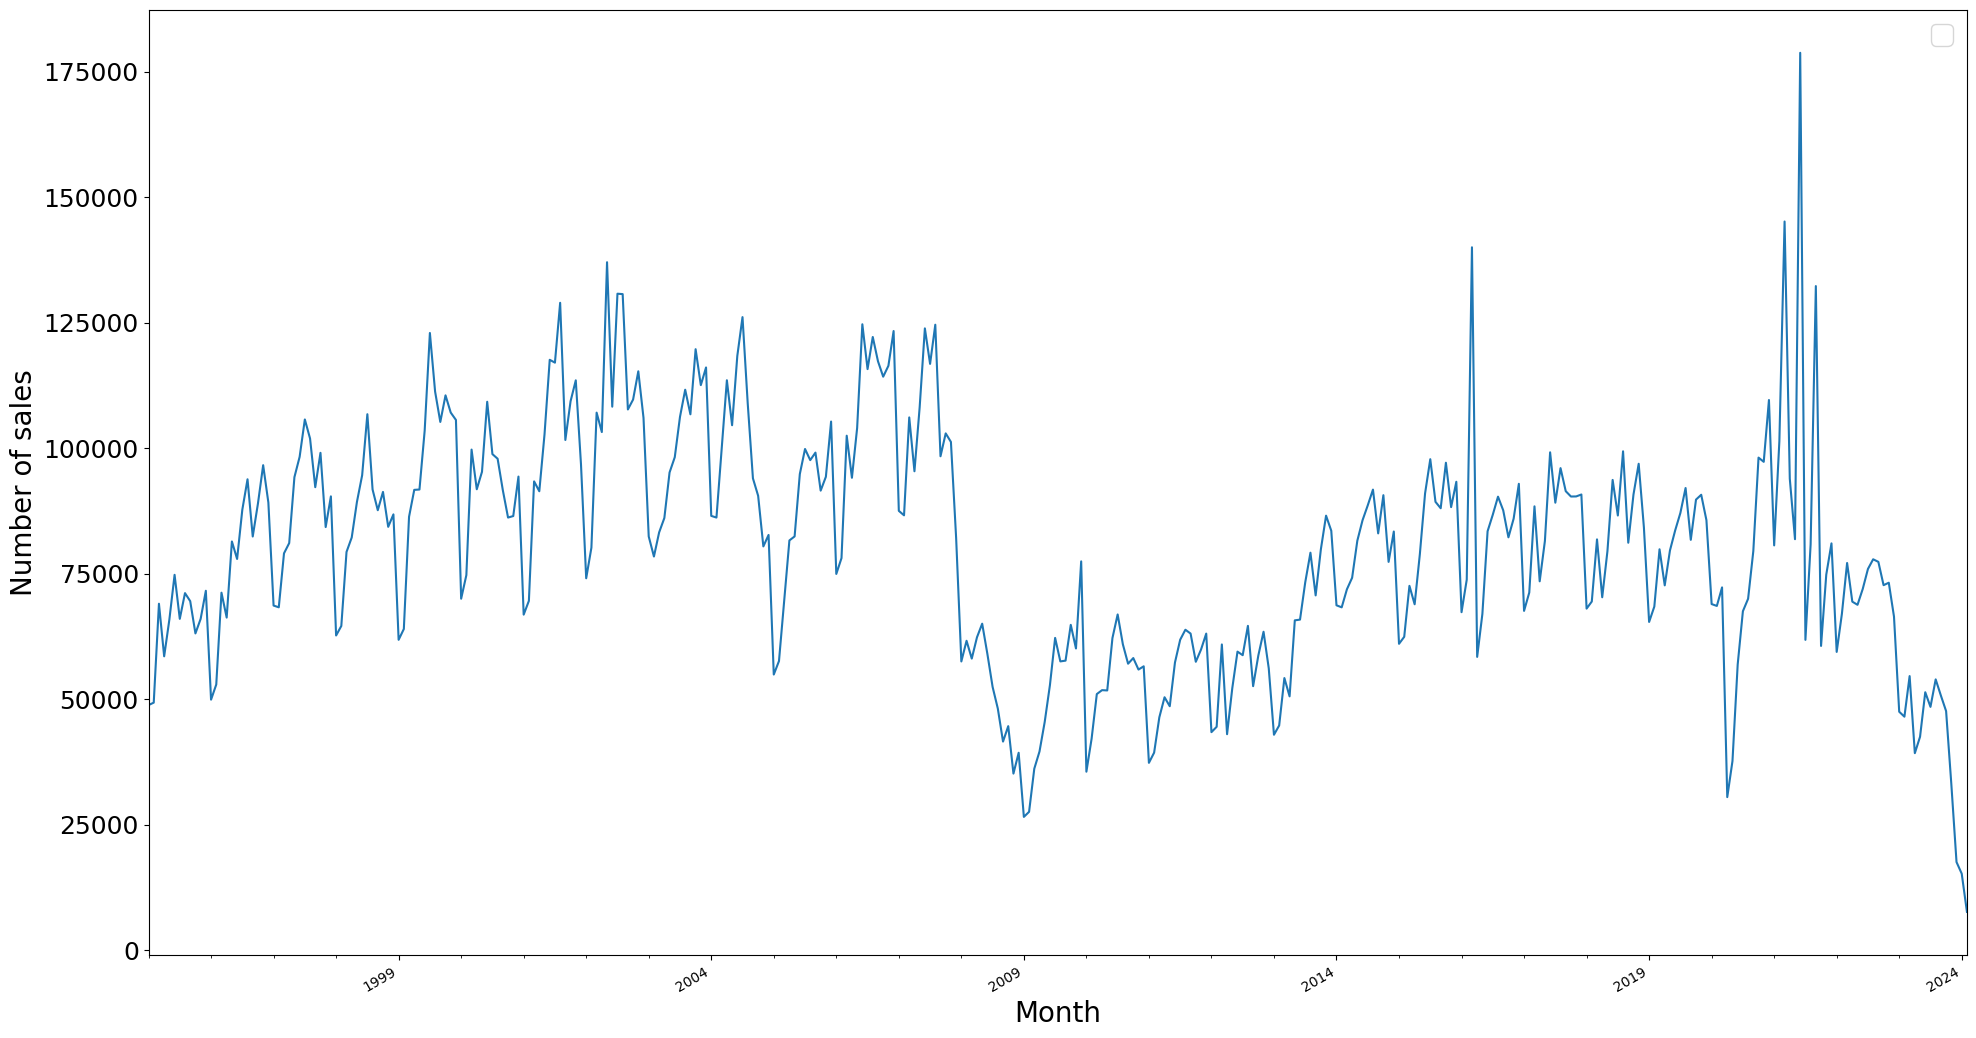

In [11]:
import matplotlib.dates as mdates
fig, ax = plt.subplots(figsize=(20,12))
grouped_version.plot(ax=ax)
plt.legend(fontsize=20)
plt.xlabel('Month', fontsize=20)
plt.ylabel('Number of sales', fontsize=20)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.gcf().autofmt_xdate()
plt.show()

In [12]:
cols = ['id', 'price', 'date', 'postcode', 'property_type', 'old_new', 'duration', 'paon', 'saon', 'street', 'locality', 'town', 'district', 'county', 'ppd_category', 'record_status']
pp_complete = pd.read_csv('../data/pp-complete.csv.1', header=0, names=cols)
pp_complete.head()

,id,price,date,postcode,property_type,old_new,duration,paon,saon,street,locality,town,district,county,ppd_category,record_status
0,{8524B47D-47ED-4C6B-97BF-D114570165DE},56950,1995-10-20 00:00,ST5 7UE,D,Y,F,2,NaN,LANGLEY CLOSE,NEWCASTLE,NEWCASTLE,NEWCASTLE-UNDER-LYME,STAFFORDSHIRE,A,A
1,{92A77299-BCFF-433B-B54D-D114861197D7},56952,1995-03-31 00:00,SE16 3EY,F,Y,L,3,FLAT 27,ROSSETTI ROAD,LONDON,LONDON,SOUTHWARK,GREATER LONDON,A,A
2,{AECA5453-F149-46BF-B3E3-CA05B7E47CE5},74000,1995-12-01 00:00,DY8 5PW,D,N,F,66,NaN,LAWNSWOOD ROAD,WORDSLEY,STOURBRIDGE,DUDLEY,WEST MIDLANDS,A,A
3,{6785BDEE-16CA-4D80-8131-CA05D4F4DBE0},155000,1995-08-09 00:00,OX39 4AF,D,Y,F,THE PANTILES,NaN,NaN,HENTON,CHINNOR,SOUTH OXFORDSHIRE,OXFORDSHIRE,A,A
4,{3FAA4BB3-40B8-4003-8C5B-D494636C6410},75000,1995-09-08 00:00,SN9 5HD,D,N,F,6,NaN,INLANDS CLOSE,PEWSEY,PEWSEY,KENNET,WILTSHIRE,A,A


In [13]:
pp_complete.loc[:, 'datey'] = pd.to_datetime(pp_complete.date)
pp_complete.loc[:, 'month_year'] = pp_complete.datey.dt.to_period('M')
big_grouped = pp_complete.groupby(['month_year']).size()
big_grouped.head()

month_year
1995-01    50485
1995-02    50856
1995-03    71296
1995-04    60289
1995-05    67855
Freq: M, dtype: int64

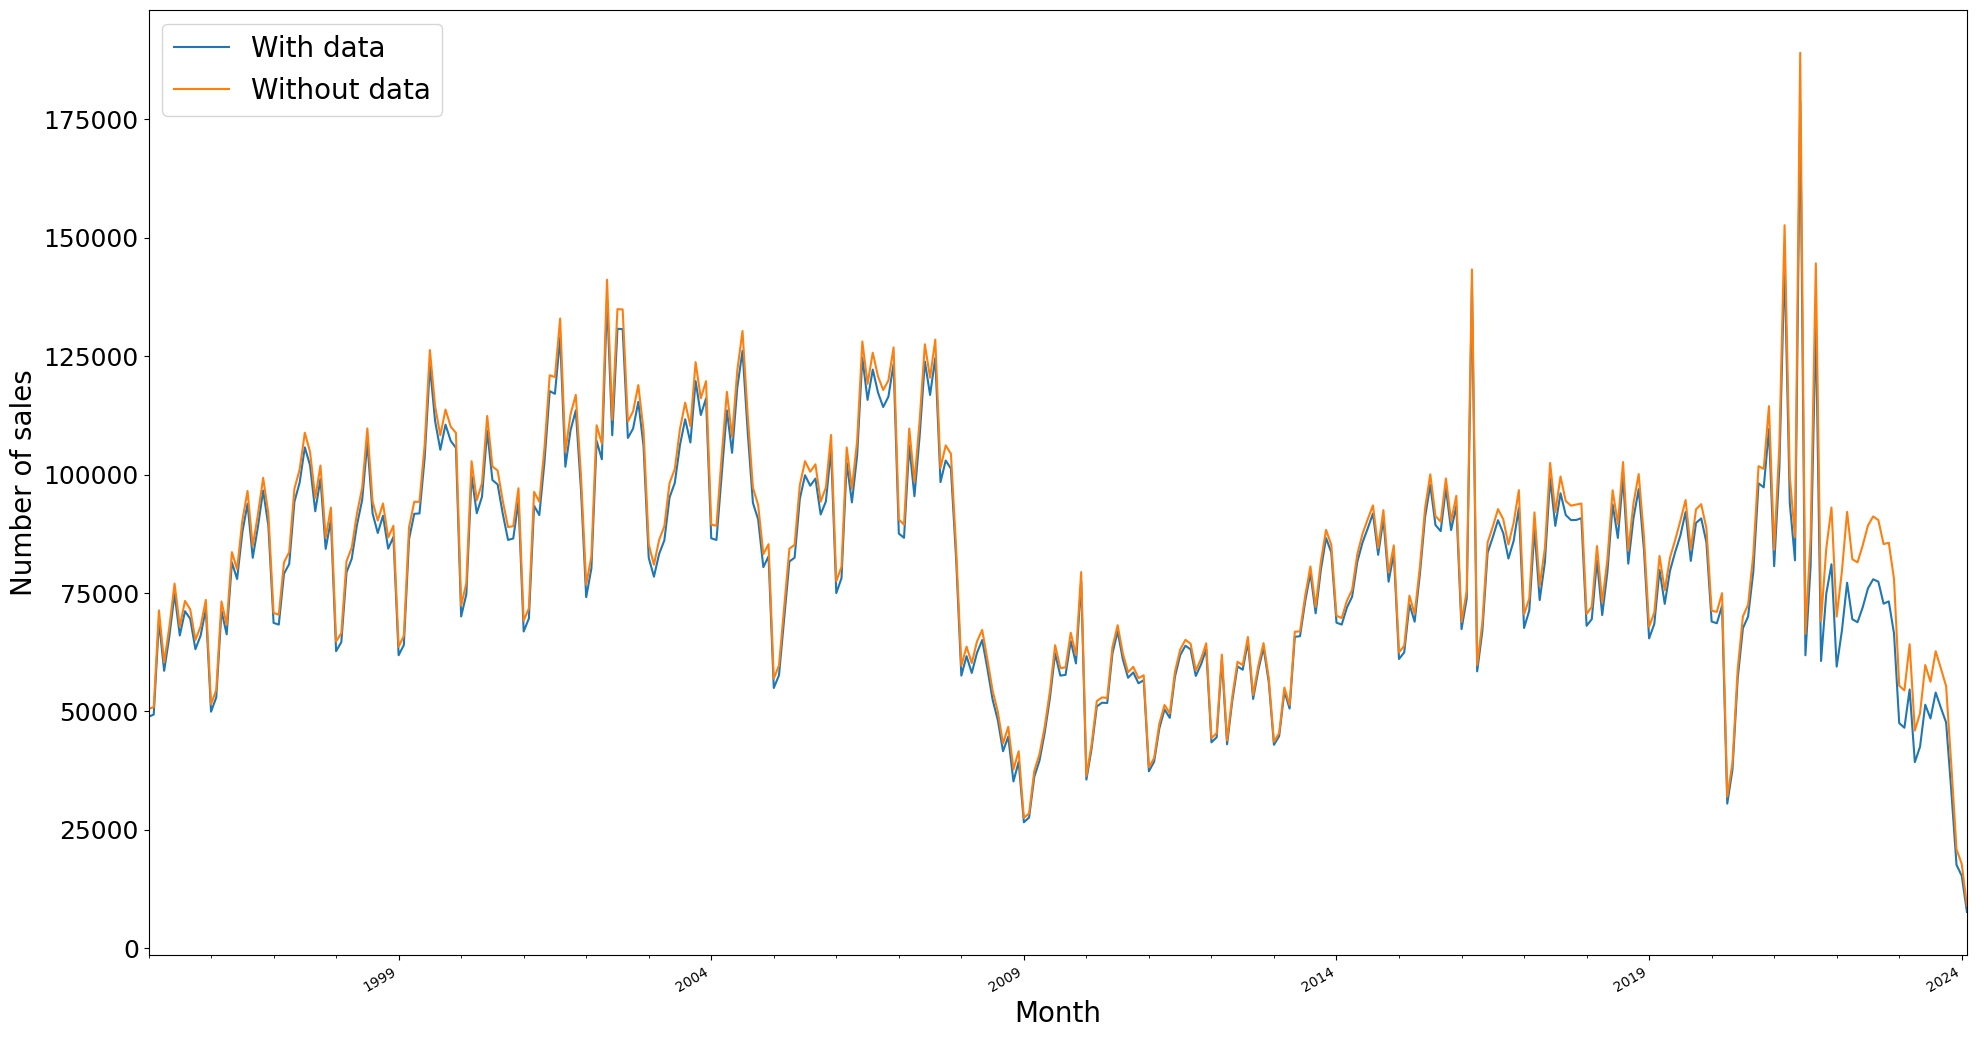

In [14]:
import matplotlib.dates as mdates
fig, ax = plt.subplots(figsize=(20,12))
grouped_version.plot(ax=ax, label='With data')
big_grouped.plot(ax=ax, label='Without data')
plt.legend(fontsize=20)
plt.xlabel('Month', fontsize=20)
plt.ylabel('Number of sales', fontsize=20)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.gcf().autofmt_xdate()
plt.show()

In [15]:
grouped_version.head()

month_year
1995-01    48822
1995-02    49307
1995-03    69015
1995-04    58536
1995-05    65859
Freq: M, dtype: int64

In [16]:
tah = big_grouped.reset_index().merge(grouped_version.reset_index(), how='inner', on='month_year')
tah.loc[:, 'data_loss'] = 100*tah['0_y'] / tah['0_x']
tah.head()

,month_year,0_x,0_y,data_loss
0,1995-01,50485,48822,96.705952
1,1995-02,50856,49307,96.954145
2,1995-03,71296,69015,96.800662
3,1995-04,60289,58536,97.092339
4,1995-05,67855,65859,97.058433


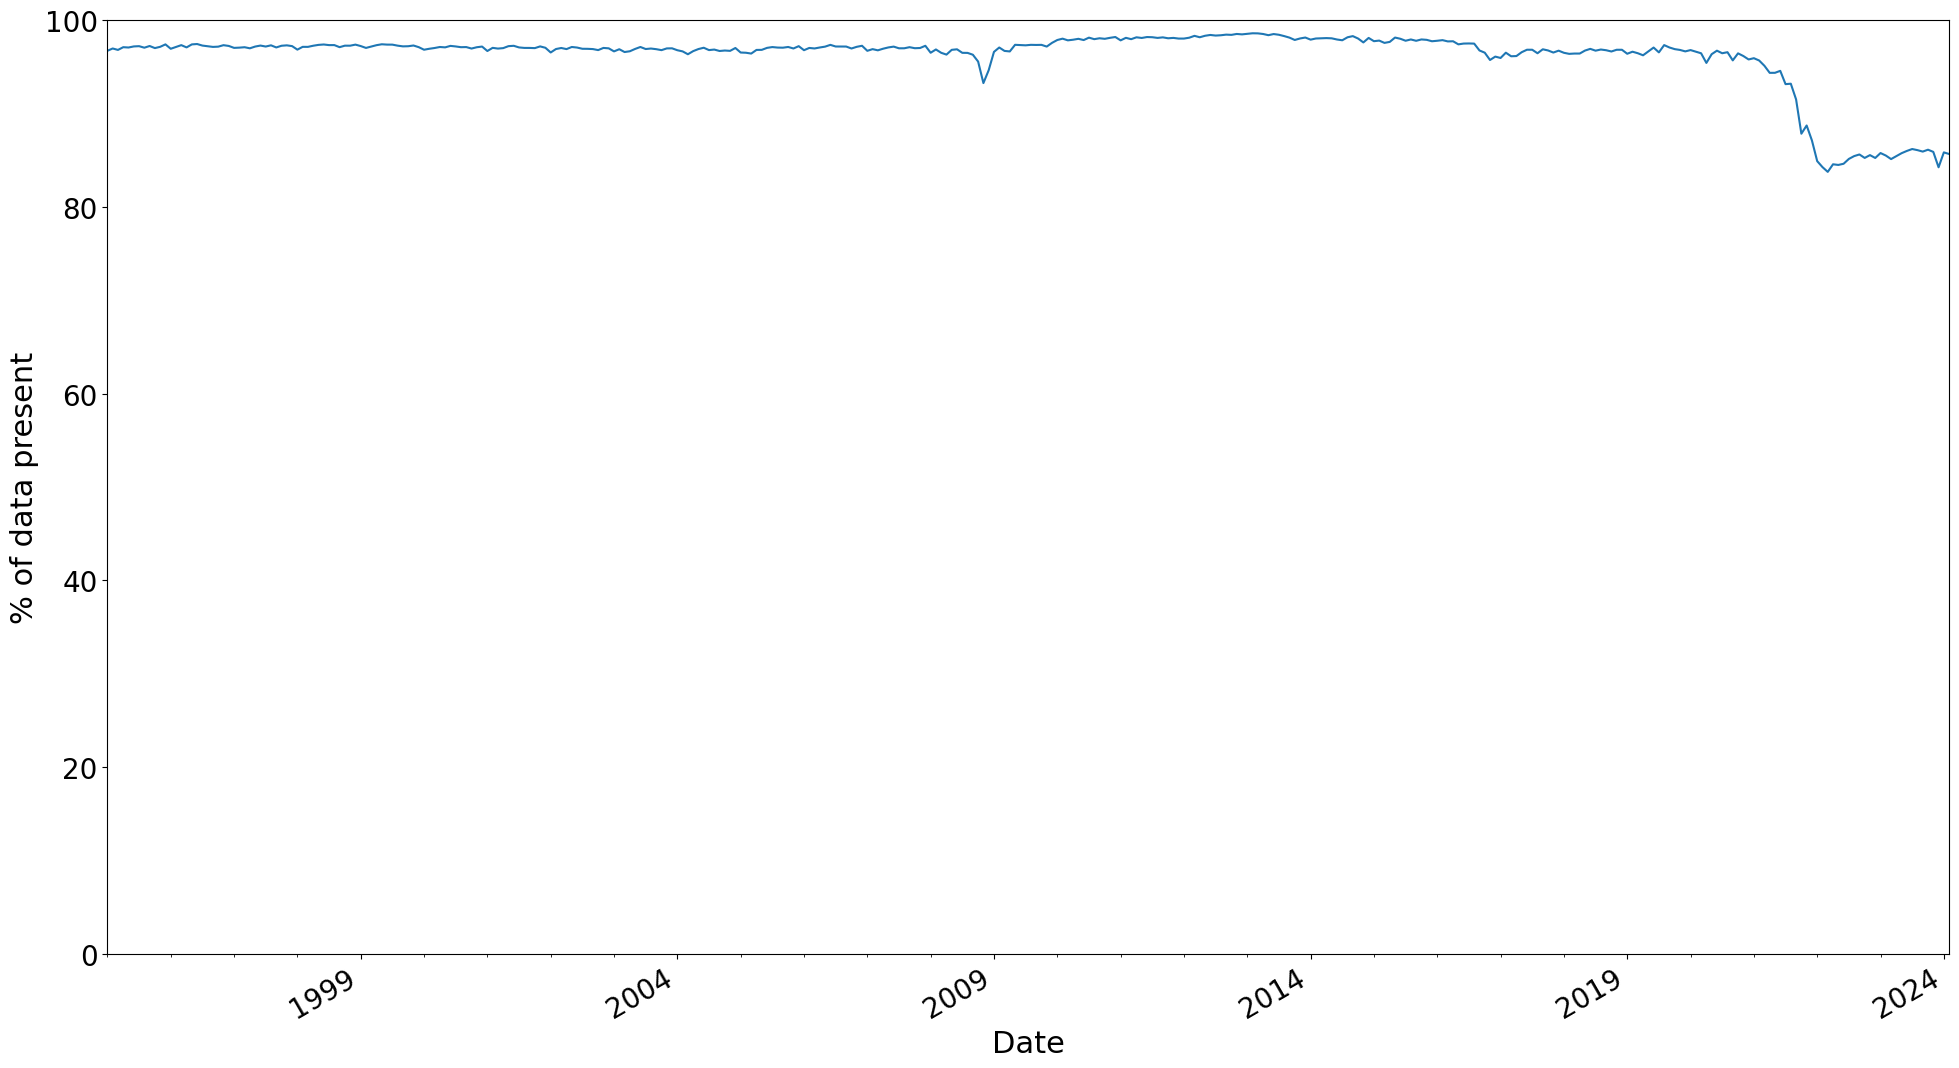

In [17]:
fig, ax = plt.subplots(figsize=(20,12))
tah.plot(ax=ax, x='month_year', y='data_loss', legend=None)
plt.xlabel('Date', fontsize=22)
plt.ylabel('% of data present', fontsize=22)
plt.yticks(fontsize=20)
plt.xticks(fontsize=20)
plt.ylim([0,100])
plt.tight_layout()
plt.gcf().autofmt_xdate()
plt.savefig('../results/pct_data_present.png')
plt.show()

In [18]:
tah.tail(50)

,month_year,0_x,0_y,data_loss
300,2020-01,71239,68947,96.782661
301,2020-02,70977,68575,96.615805
302,2020-03,74934,72267,96.440868
303,2020-04,31950,30483,95.408451
304,2020-05,39102,37672,96.342898
305,2020-06,58837,56907,96.719751
306,2020-07,70011,67522,96.444844
307,2020-08,72503,70006,96.556005
308,2020-09,83102,79512,95.680008
309,2020-10,101760,98130,96.432783


In [19]:
del pp_complete

In [20]:
smaller.head()

,Unnamed: 0,id,price,date,postcode,property_type,old_new,duration,paon,saon,...,y_coord,lat,lon,OA11CD,LAD22NM,RUC11CD,RUC11,datey,month_year,urb_rur
0,0,{8524B47D-47ED-4C6B-97BF-D114570165DE},56950,1995-10-20 00:00,ST5 7UE,D,Y,F,2,NaN,...,350560.34,53.052039,-2.257366,E00150541,Newcastle-under-Lyme,C1,Urban city and town,1995-10-20,1995-10,Urban
1,1,{92A77299-BCFF-433B-B54D-D114861197D7},56952,1995-03-31 00:00,SE16 3EY,F,Y,L,3,FLAT 27,...,178381.00,51.488331,-0.060520,E00020342,Southwark,A1,Urban major conurbation,1995-03-31,1995-03,Urban
2,2,{AECA5453-F149-46BF-B3E3-CA05B7E47CE5},74000,1995-12-01 00:00,DY8 5PW,D,N,F,66,NaN,...,287130.00,52.481988,-2.167445,E00050170,Dudley,A1,Urban major conurbation,1995-12-01,1995-12,Urban
3,3,{6785BDEE-16CA-4D80-8131-CA05D4F4DBE0},155000,1995-08-09 00:00,OX39 4AF,D,Y,F,THE PANTILES,NaN,...,202835.00,51.719093,-0.899908,E00145755,South Oxfordshire,F1,Rural hamlets and isolated dwellings,1995-08-09,1995-08,Rural
4,4,{3FAA4BB3-40B8-4003-8C5B-D494636C6410},75000,1995-09-08 00:00,SN9 5HD,D,N,F,6,NaN,...,160302.00,51.341568,-1.766247,E00162545,Wiltshire,D1,Rural town and fringe,1995-09-08,1995-09,Rural


In [21]:
smaller.groupby('RUC11').describe()

Unnamed: 0                \
                                                         count          mean   
RUC11                                                                          
Rural hamlets and isolated dwellings                  663460.0  1.544646e+07   
Rural hamlets and isolated dwellings in a spars...     78614.0  1.490371e+07   
Rural town and fringe                                2748569.0  1.426480e+07   
Rural town and fringe in a sparse setting             166427.0  1.419304e+07   
Rural village                                        1359805.0  1.452015e+07   
Rural village in a sparse setting                     137580.0  1.413192e+07   
Urban city and town                                 13548498.0  1.384180e+07   
Urban city and town in a sparse setting                75938.0  1.390491e+07   
Urban major conurbation                              8273833.0  1.378924e+07   
Urban minor conurbation                               866982.0  1.429689e+07   

                                                                       \
                                                      min         25%   
RUC11                                                                   
Rural hamlets and isolated dwellings                  3.0  8074981.00   
Rural hamlets and isolated dwellings in a spars...   10.0  7806859.00   
Rural town and fringe                                 4.0  7139359.00   
Rural town and fringe in a sparse setting           290.0  7210641.00   
Rural village                                        11.0  7242546.00   
Rural village in a sparse setting                    79.0  7040538.75   
Urban city and town                                   0.0  6885516.25   
Urban city and town in a sparse setting             111.0  6938724.75   
Urban major conurbation                               1.0  6910365.00   
Urban minor conurbation                              13.0  7465855.25   

                                                                             \
                                                           50%          75%   
RUC11                                                                         
Rural hamlets and isolated dwellings                16560463.0  22942467.00   
Rural hamlets and isolated dwellings in a spars...  15668599.5  22212355.25   
Rural town and fringe                               14561048.0  21384927.00   
Rural town and fringe in a sparse setting           14545829.0  21291767.50   
Rural village                                       15100440.0  21837102.00   
Rural village in a sparse setting                   14549094.0  21339386.00   
Urban city and town                                 13784409.0  20761444.50   
Urban city and town in a sparse setting             13968013.0  20995720.75   
Urban major conurbation                             13657670.0  20629335.00   
Urban minor conurbation                             14246486.0  21417565.25   

                                                                              \
                                                           max           std   
RUC11                                                                          
Rural hamlets and isolated dwellings                27919556.0  8.341552e+06   
Rural hamlets and isolated dwellings in a spars...  27918485.0  8.077311e+06   
Rural town and fringe                               27919704.0  8.134470e+06   
Rural town and fringe in a sparse setting           27919087.0  8.005504e+06   
Rural village                                       27919589.0  8.227063e+06   
Rural village in a sparse setting                   27918722.0  8.021589e+06   
Urban city and town                                 27919688.0  8.034475e+06   
Urban city and town in a sparse setting             27918887.0  8.018675e+06   
Urban major conurbation                             27919679.0  8.005658e+06   
Urban minor conurbation                             27919705.0  8.066184e

In [54]:
reference_dist = smaller[smaller.urb_rur == 'Urban']
reference_dist.head()

,Unnamed: 0,id,price,date,postcode,property_type,old_new,duration,paon,saon,...,y_coord,lat,lon,OA11CD,LAD22NM,RUC11CD,RUC11,datey,month_year,urb_rur
0,0,{8524B47D-47ED-4C6B-97BF-D114570165DE},56950,1995-10-20 00:00,ST5 7UE,D,Y,F,2,NaN,...,350560.34,53.052039,-2.257366,E00150541,Newcastle-under-Lyme,C1,Urban city and town,1995-10-20,1995-10,Urban
1,1,{92A77299-BCFF-433B-B54D-D114861197D7},56952,1995-03-31 00:00,SE16 3EY,F,Y,L,3,FLAT 27,...,178381.00,51.488331,-0.060520,E00020342,Southwark,A1,Urban major conurbation,1995-03-31,1995-03,Urban
2,2,{AECA5453-F149-46BF-B3E3-CA05B7E47CE5},74000,1995-12-01 00:00,DY8 5PW,D,N,F,66,NaN,...,287130.00,52.481988,-2.167445,E00050170,Dudley,A1,Urban major conurbation,1995-12-01,1995-12,Urban
5,5,{49A6A979-61D4-4F09-89C8-D4946C42987E},12500,1995-08-25 00:00,OL13 0EA,T,N,L,10,NaN,...,421707.00,53.691641,-2.209593,E00128748,Rossendale,C1,Urban city and town,1995-08-25,1995-08,Urban
6,6,{5B214183-34D5-4933-93A1-D4946DE93137},60000,1995-11-17 00:00,TW11 9DR,T,N,F,13,NaN,...,170168.94,51.418457,-0.317854,E00019300,Richmond upon Thames,A1,Urban major conurbation,1995-11-17,1995-11,Urban


In [55]:
base = reference_dist.groupby('month_year').price.mean().reset_index()
base.columns = ['month_year', 'avg_price_base']

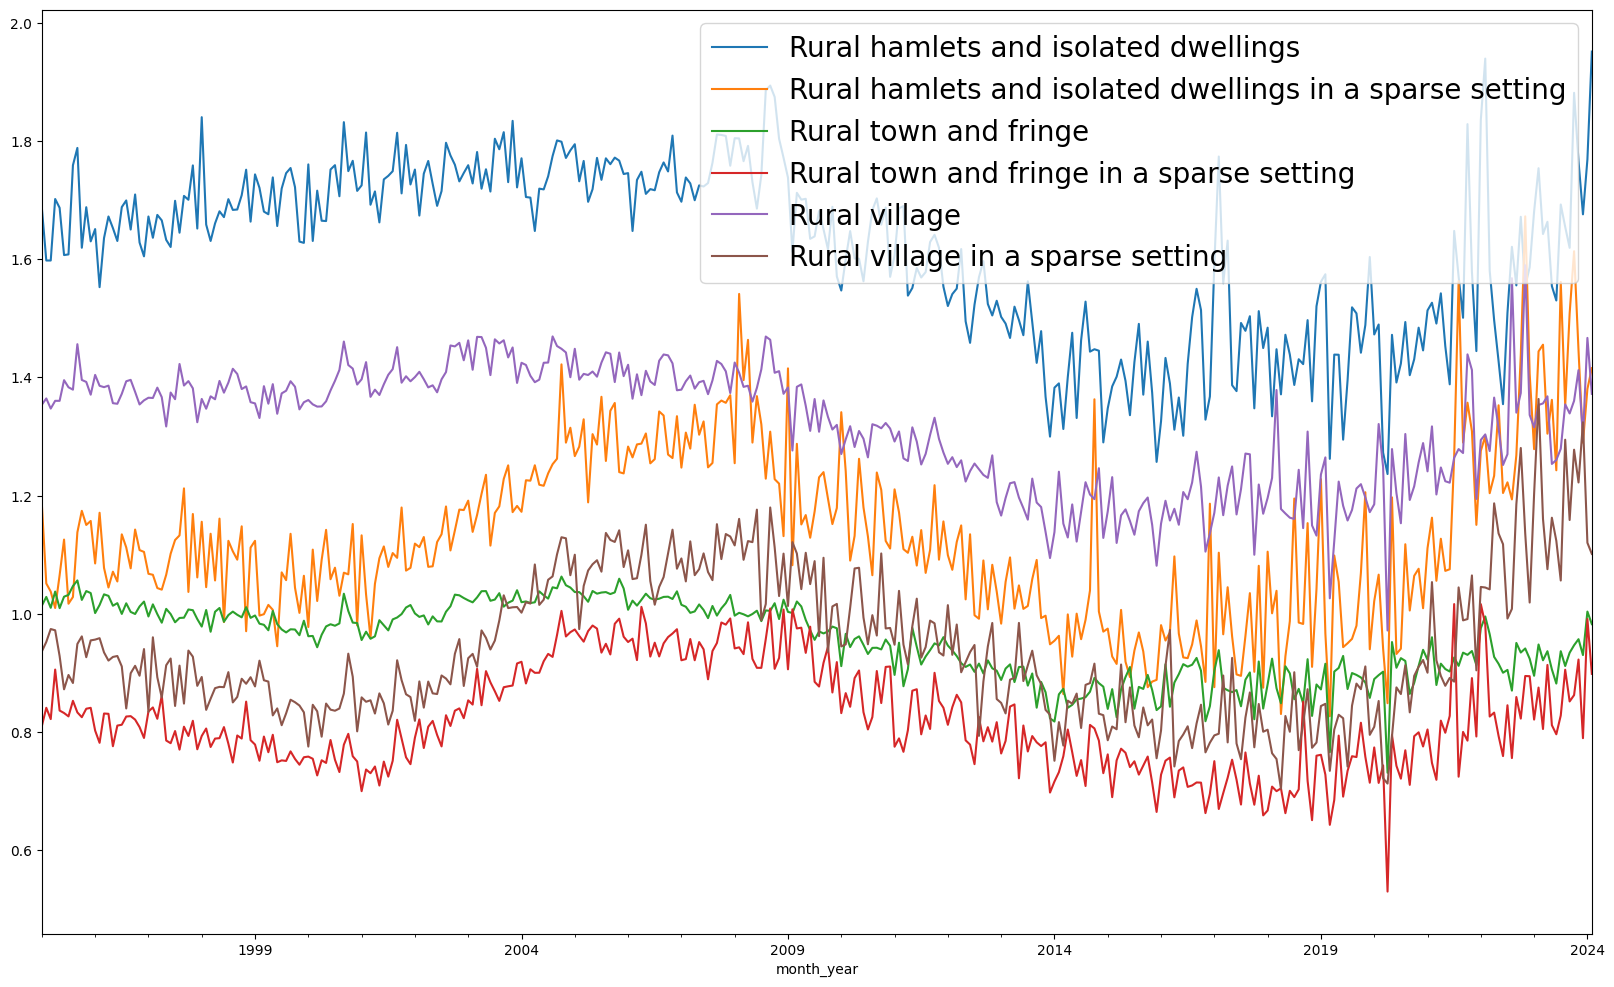

In [56]:
fig, ax = plt.subplots(figsize=(20,12))
for idx, frame in smaller[(smaller.RUC11 != 'Urban city and town') & (smaller.urb_rur == 'Rural')].groupby('RUC11'):
    groupy = frame.groupby('month_year').price.mean().reset_index()
    groupy.columns = ['month_year', 'avg_price']
    merge = groupy.merge(base, how='inner', on=['month_year'])
    merge.loc[:, 'pct_base'] = merge.avg_price / merge.avg_price_base
    merge.plot(ax=ax, y='pct_base', x='month_year', label=idx)

plt.legend(fontsize=20)
plt.show()

In [57]:
merge.head()

,month_year,avg_price,avg_price_base,pct_base
0,1995-01,61358.174468,65539.883577,0.936196
1,1995-02,60313.278761,63330.604718,0.952356
2,1995-03,62015.675325,63662.240732,0.974136
3,1995-04,63242.081448,65063.798083,0.972001
4,1995-05,60045.154110,64671.863214,0.928459


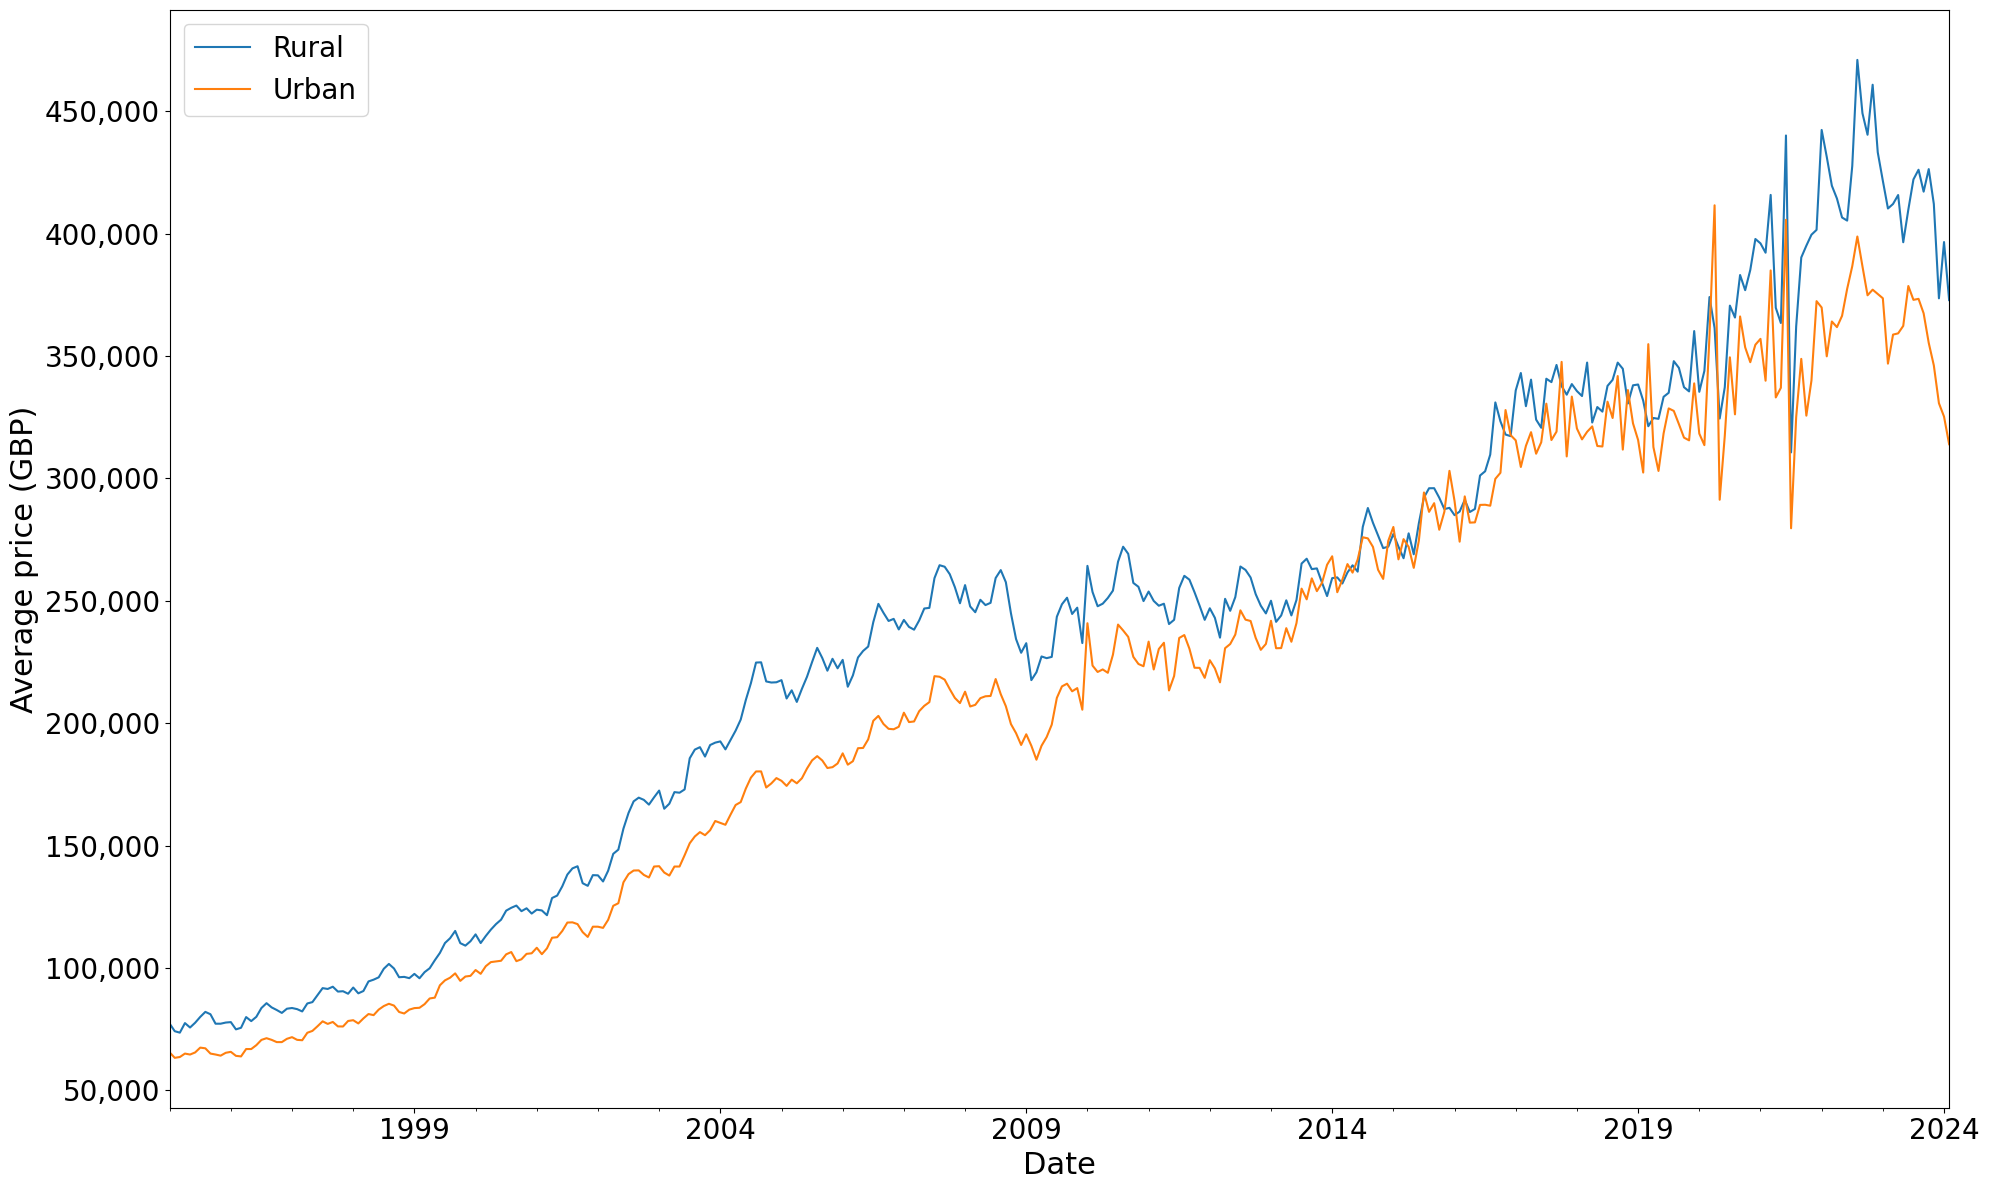

In [58]:
import matplotlib as mpl

fig, ax = plt.subplots(figsize=(20,12))
rural = smaller[smaller.urb_rur == 'Rural']
rural = rural.groupby('month_year').price.mean().reset_index()
rural.columns = ['month_year', 'avg_price_base']

rural.plot(ax=ax, x='month_year', y='avg_price_base', label='Rural')
base.plot(ax=ax, x='month_year', y='avg_price_base', label='Urban')
ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
plt.legend(fontsize=20)
plt.xlabel('Date', fontsize=22)
plt.xticks(fontsize=20)
plt.ylabel('Average price (GBP)', fontsize=22)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.savefig('../results/avg_price_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

In [59]:
mergey = base.merge(rural, how='inner', on='month_year', suffixes=('_urban', '_rural'))
mergey.head()

,month_year,avg_price_base_urban,avg_price_base_rural
0,1995-01,65539.883577,77288.387649
1,1995-02,63330.604718,74201.000821
2,1995-03,63662.240732,73613.260304
3,1995-04,65063.798083,77518.322790
4,1995-05,64671.863214,75712.538319


In [60]:
mergey.loc[:, 'pct_sale_price'] = 100*((mergey.avg_price_base_rural/mergey.avg_price_base_urban)-1)
mergey.head()

,month_year,avg_price_base_urban,avg_price_base_rural,pct_sale_price
0,1995-01,65539.883577,77288.387649,17.925732
1,1995-02,63330.604718,74201.000821,17.164523
2,1995-03,63662.240732,73613.260304,15.630960
3,1995-04,65063.798083,77518.322790,19.142019
4,1995-05,64671.863214,75712.538319,17.071837


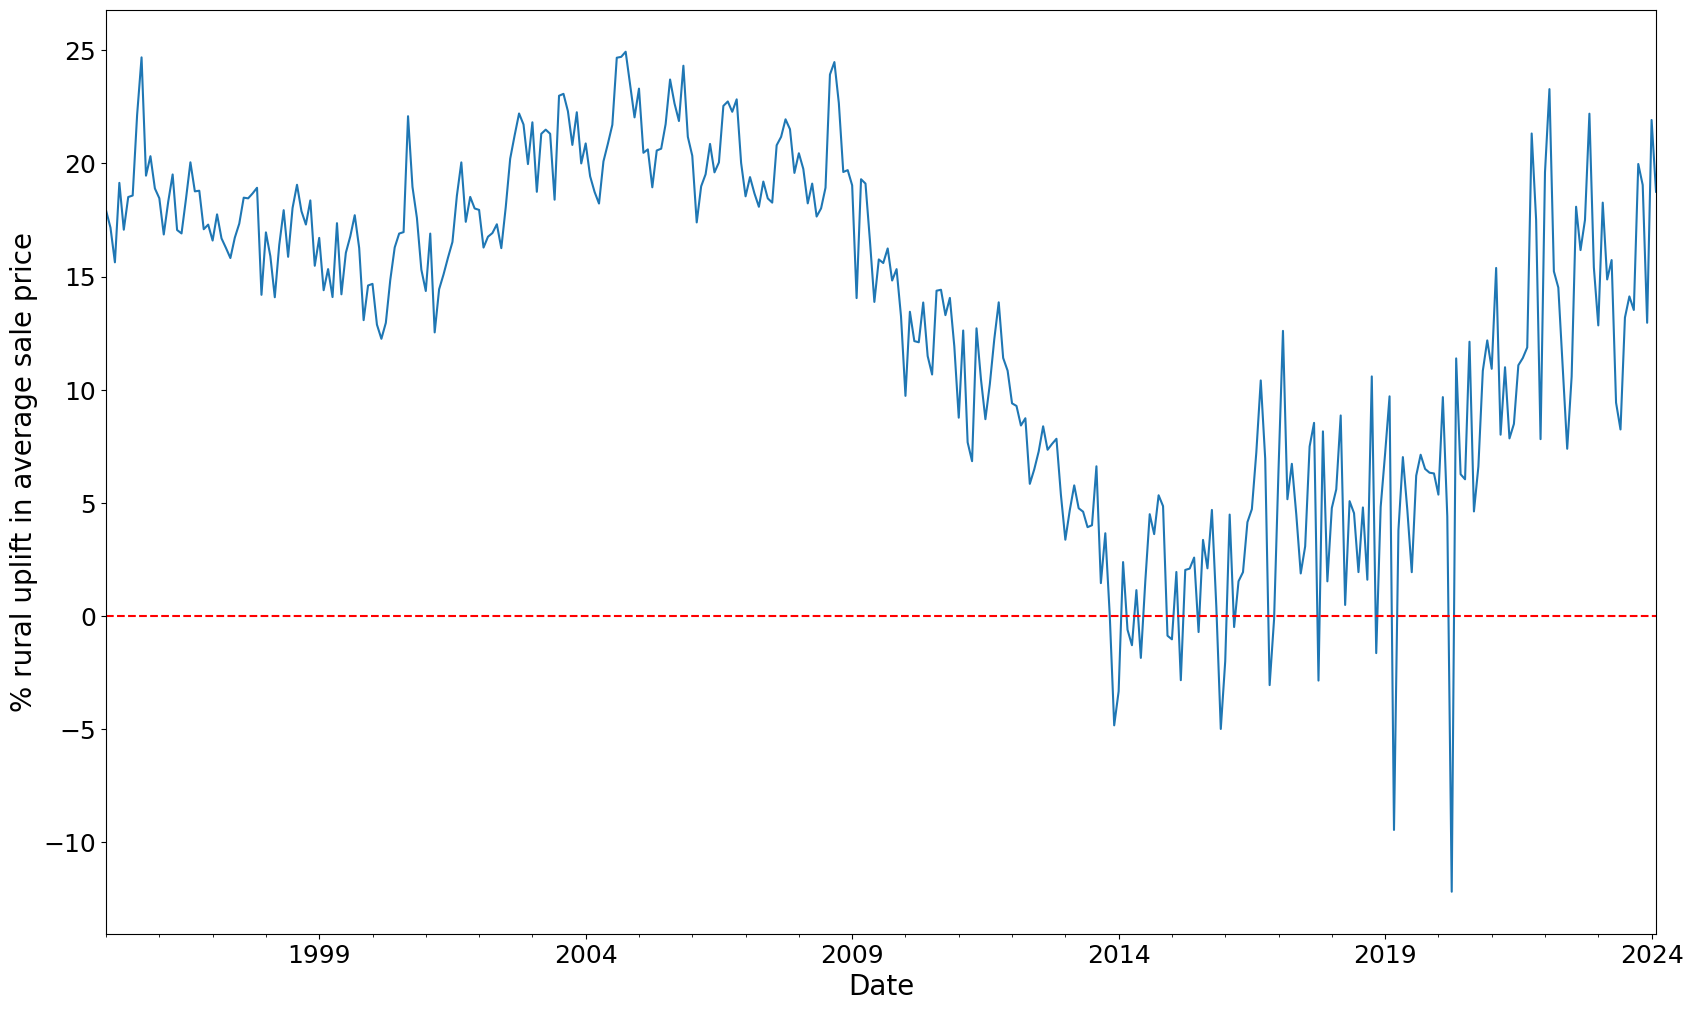

In [61]:
fig, ax = plt.subplots(figsize=(20,12))

mergey.plot(ax=ax, x='month_year', y='pct_sale_price', legend=None)
plt.axhline(y=0, ls='dashed', color='red')
plt.xlabel('Date', fontsize=20)
plt.ylabel('% rural uplift in average sale price', fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.savefig('../results/rural_pct_avg_sale_price_uplift.png', dpi=300, bbox_inches='tight')
plt.show()

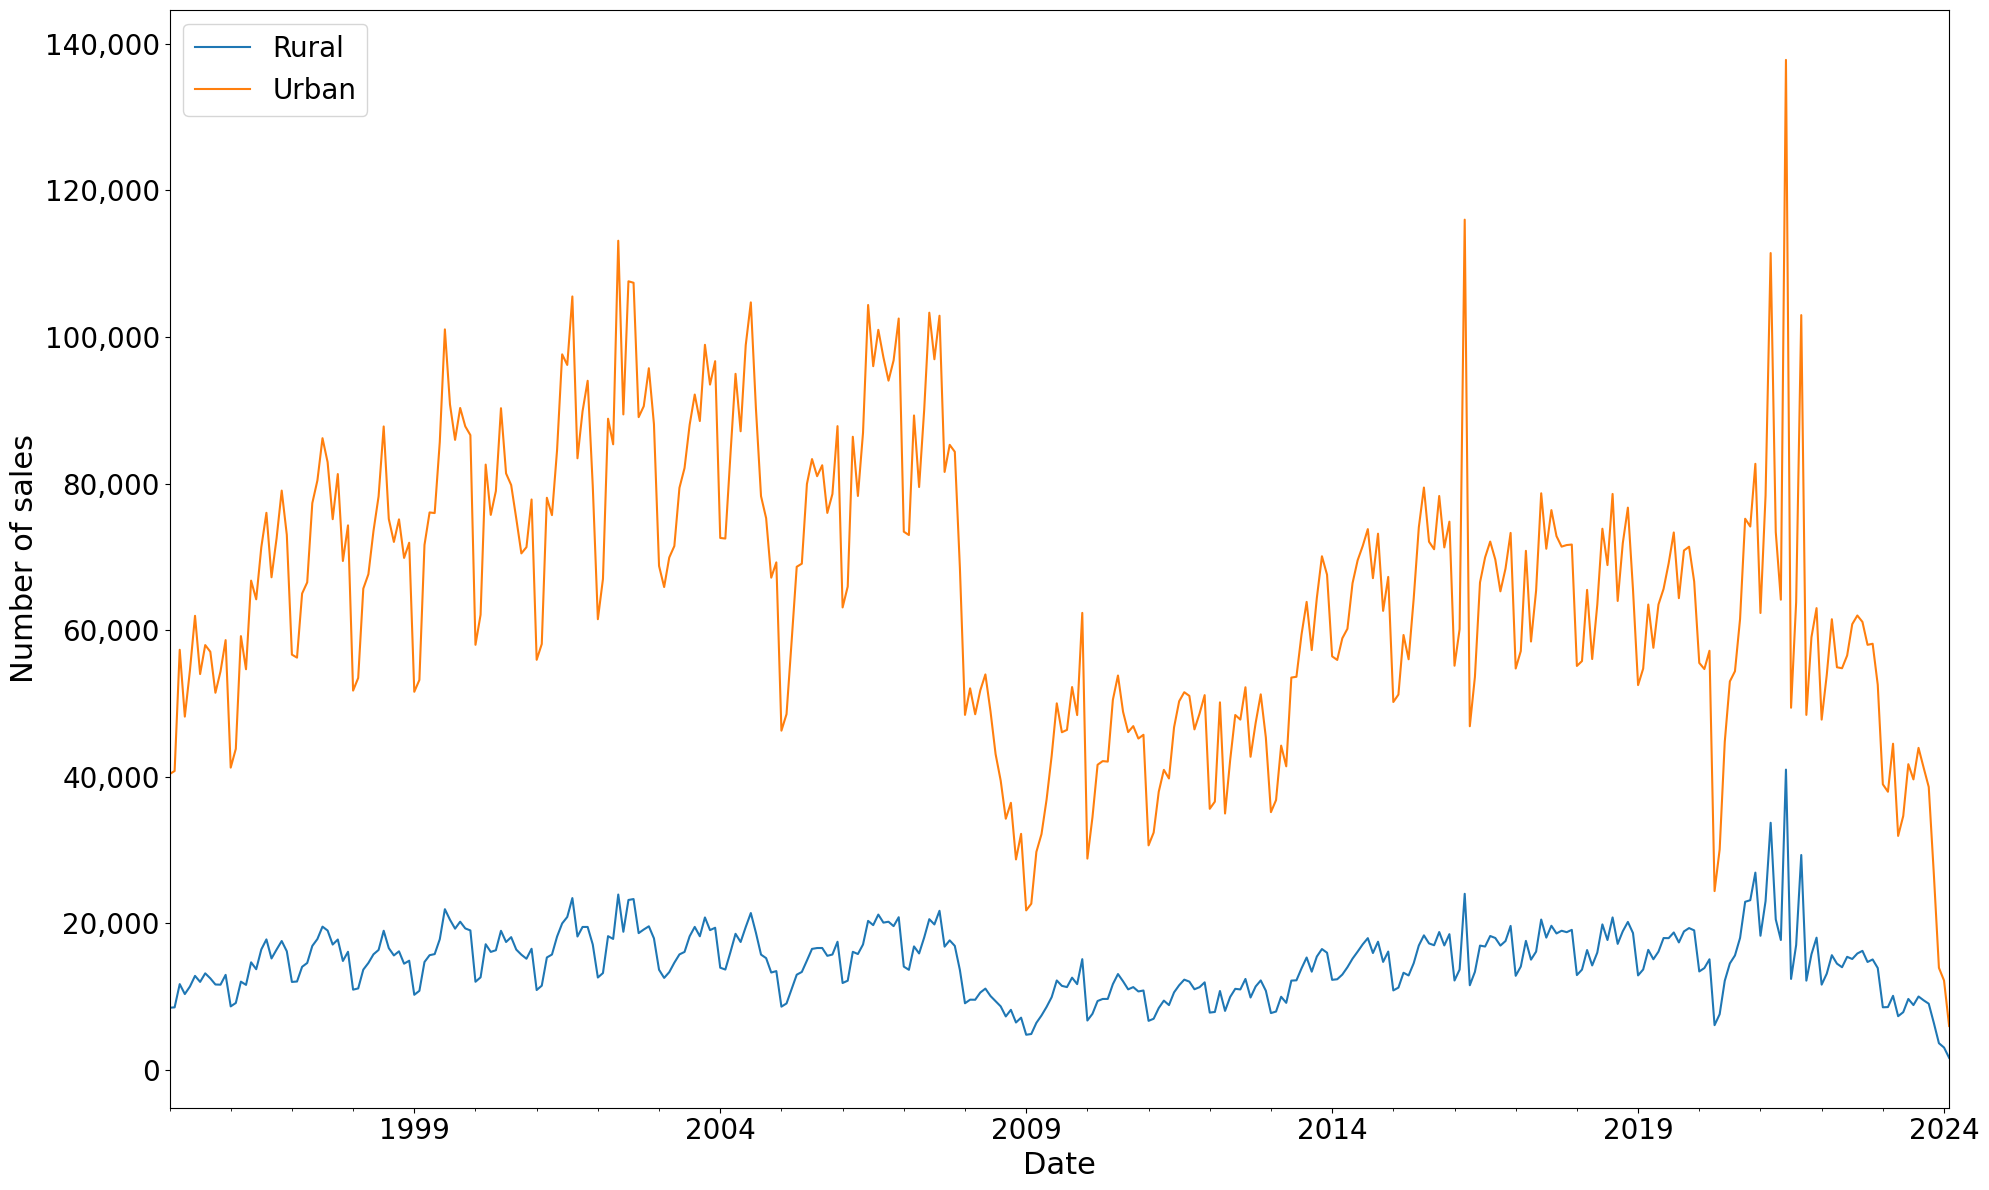

In [30]:
import matplotlib as mpl

fig, ax = plt.subplots(figsize=(20,12))
rural = smaller[smaller.urb_rur == 'Rural']
rural = rural.groupby('month_year').price.size().reset_index()
rural.columns = ['month_year', 'num_sales']

base_sales = smaller[smaller.urb_rur == 'Urban']
base_sales = base_sales.groupby('month_year').price.size().reset_index()
base_sales.columns = ['month_year', 'num_sales']

rural.plot(ax=ax, x='month_year', y='num_sales', label='Rural')
base_sales.plot(ax=ax, x='month_year', y='num_sales', label='Urban')
ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
plt.legend(fontsize=20)
plt.xlabel('Date', fontsize=22)
plt.xticks(fontsize=20)
plt.ylabel('Number of sales', fontsize=22)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.savefig('../results/num_sales_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

In [31]:
rural.head()

,month_year,num_sales
0,1995-01,8469
1,1995-02,8526
2,1995-03,11694
3,1995-04,10338
4,1995-05,11365


In [32]:
base_sales.head()

,month_year,num_sales
0,1995-01,40353
1,1995-02,40781
2,1995-03,57321
3,1995-04,48198
4,1995-05,54494


In [33]:
mergey = base_sales.merge(rural, how='inner', on='month_year', suffixes=('_urban', '_rural'))
mergey.head()

,month_year,num_sales_urban,num_sales_rural
0,1995-01,40353,8469
1,1995-02,40781,8526
2,1995-03,57321,11694
3,1995-04,48198,10338
4,1995-05,54494,11365


In [34]:
mergey.loc[:, 'pct_sales'] = 100*(mergey.num_sales_rural)/(mergey.num_sales_rural + mergey.num_sales_urban)
mergey.head()

,month_year,num_sales_urban,num_sales_rural,pct_sales
0,1995-01,40353,8469,17.346688
1,1995-02,40781,8526,17.291662
2,1995-03,57321,11694,16.944143
3,1995-04,48198,10338,17.660927
4,1995-05,54494,11365,17.256563


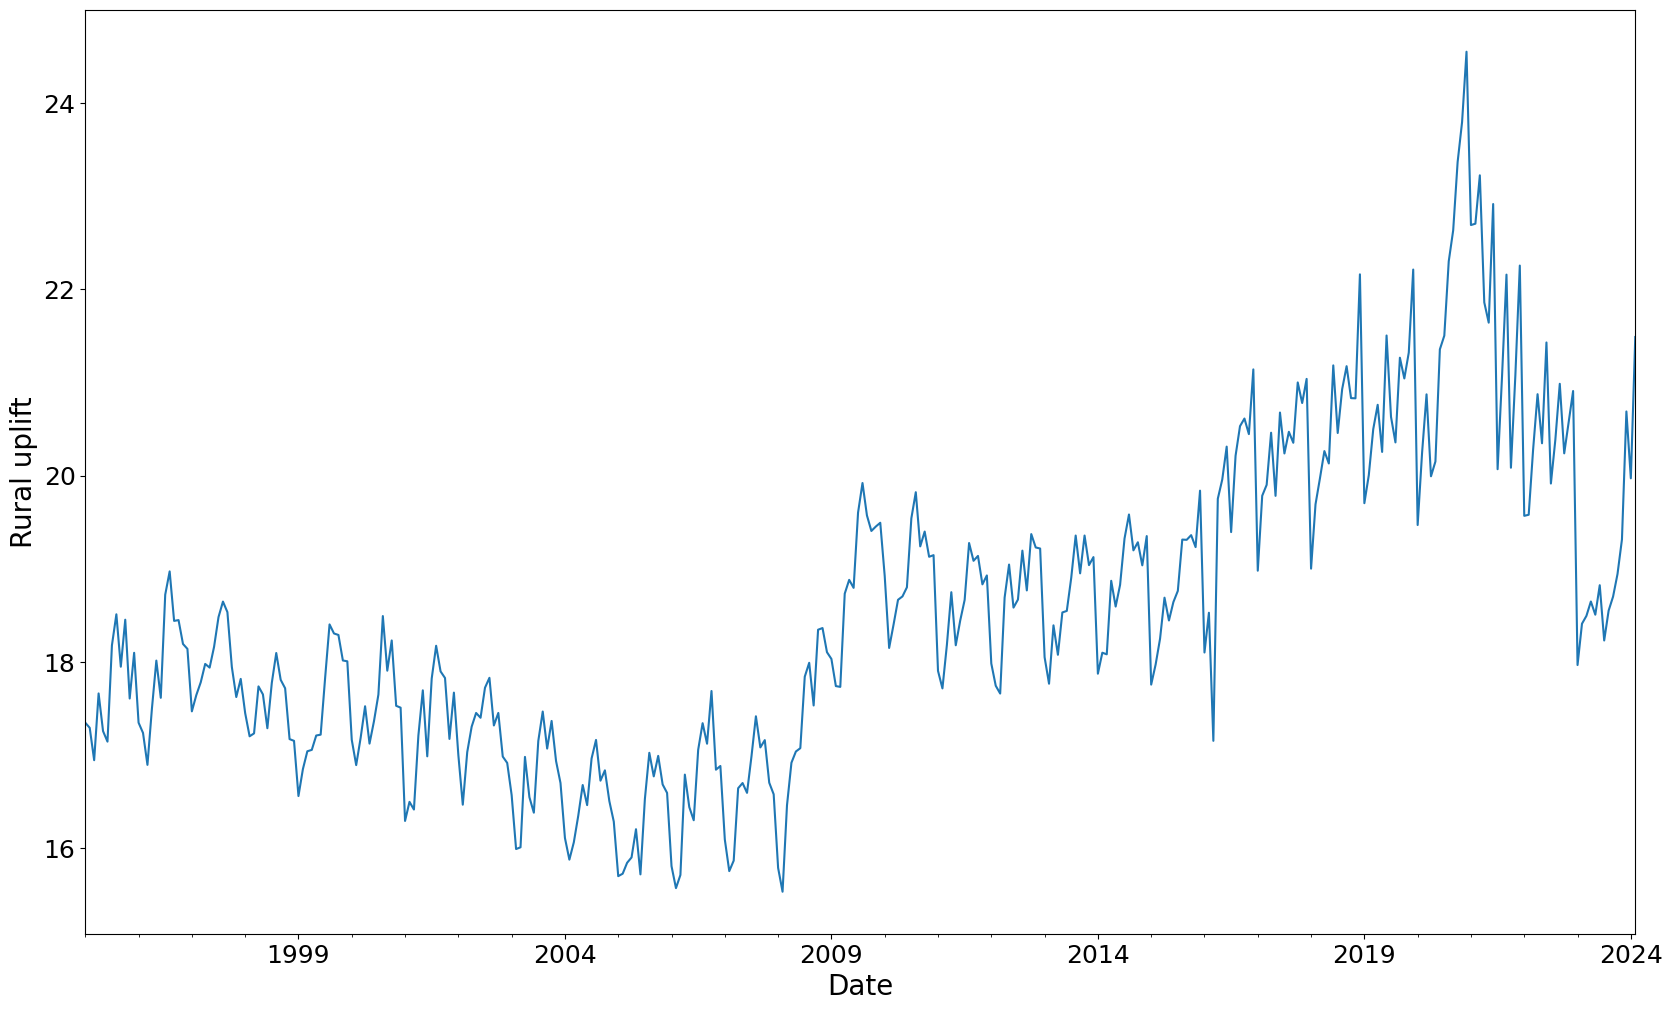

In [35]:
fig, ax = plt.subplots(figsize=(20,12))

mergey.plot(ax=ax, x='month_year', y='pct_sales', legend=None)
#plt.axhline(y=0, ls='dashed', color='red')
plt.xlabel('Date', fontsize=20)
plt.ylabel('Rural uplift', fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.savefig('../results/pct_house_sales_in_rural_areas.png', dpi=300, bbox_inches='tight')
plt.show()

In [36]:
smaller.head()

,Unnamed: 0,id,price,date,postcode,property_type,old_new,duration,paon,saon,...,y_coord,lat,lon,OA11CD,LAD22NM,RUC11CD,RUC11,datey,month_year,urb_rur
0,0,{8524B47D-47ED-4C6B-97BF-D114570165DE},56950,1995-10-20 00:00,ST5 7UE,D,Y,F,2,NaN,...,350560.34,53.052039,-2.257366,E00150541,Newcastle-under-Lyme,C1,Urban city and town,1995-10-20,1995-10,Urban
1,1,{92A77299-BCFF-433B-B54D-D114861197D7},56952,1995-03-31 00:00,SE16 3EY,F,Y,L,3,FLAT 27,...,178381.00,51.488331,-0.060520,E00020342,Southwark,A1,Urban major conurbation,1995-03-31,1995-03,Urban
2,2,{AECA5453-F149-46BF-B3E3-CA05B7E47CE5},74000,1995-12-01 00:00,DY8 5PW,D,N,F,66,NaN,...,287130.00,52.481988,-2.167445,E00050170,Dudley,A1,Urban major conurbation,1995-12-01,1995-12,Urban
3,3,{6785BDEE-16CA-4D80-8131-CA05D4F4DBE0},155000,1995-08-09 00:00,OX39 4AF,D,Y,F,THE PANTILES,NaN,...,202835.00,51.719093,-0.899908,E00145755,South Oxfordshire,F1,Rural hamlets and isolated dwellings,1995-08-09,1995-08,Rural
4,4,{3FAA4BB3-40B8-4003-8C5B-D494636C6410},75000,1995-09-08 00:00,SN9 5HD,D,N,F,6,NaN,...,160302.00,51.341568,-1.766247,E00162545,Wiltshire,D1,Rural town and fringe,1995-09-08,1995-09,Rural


In [37]:
smaller.groupby('LAD22NM').size().sort_values(ascending=False).head(5).index


Index(['Birmingham', 'Leeds', 'Cornwall', 'Buckinghamshire', 'Wiltshire'], dtype='object', name='LAD22NM')

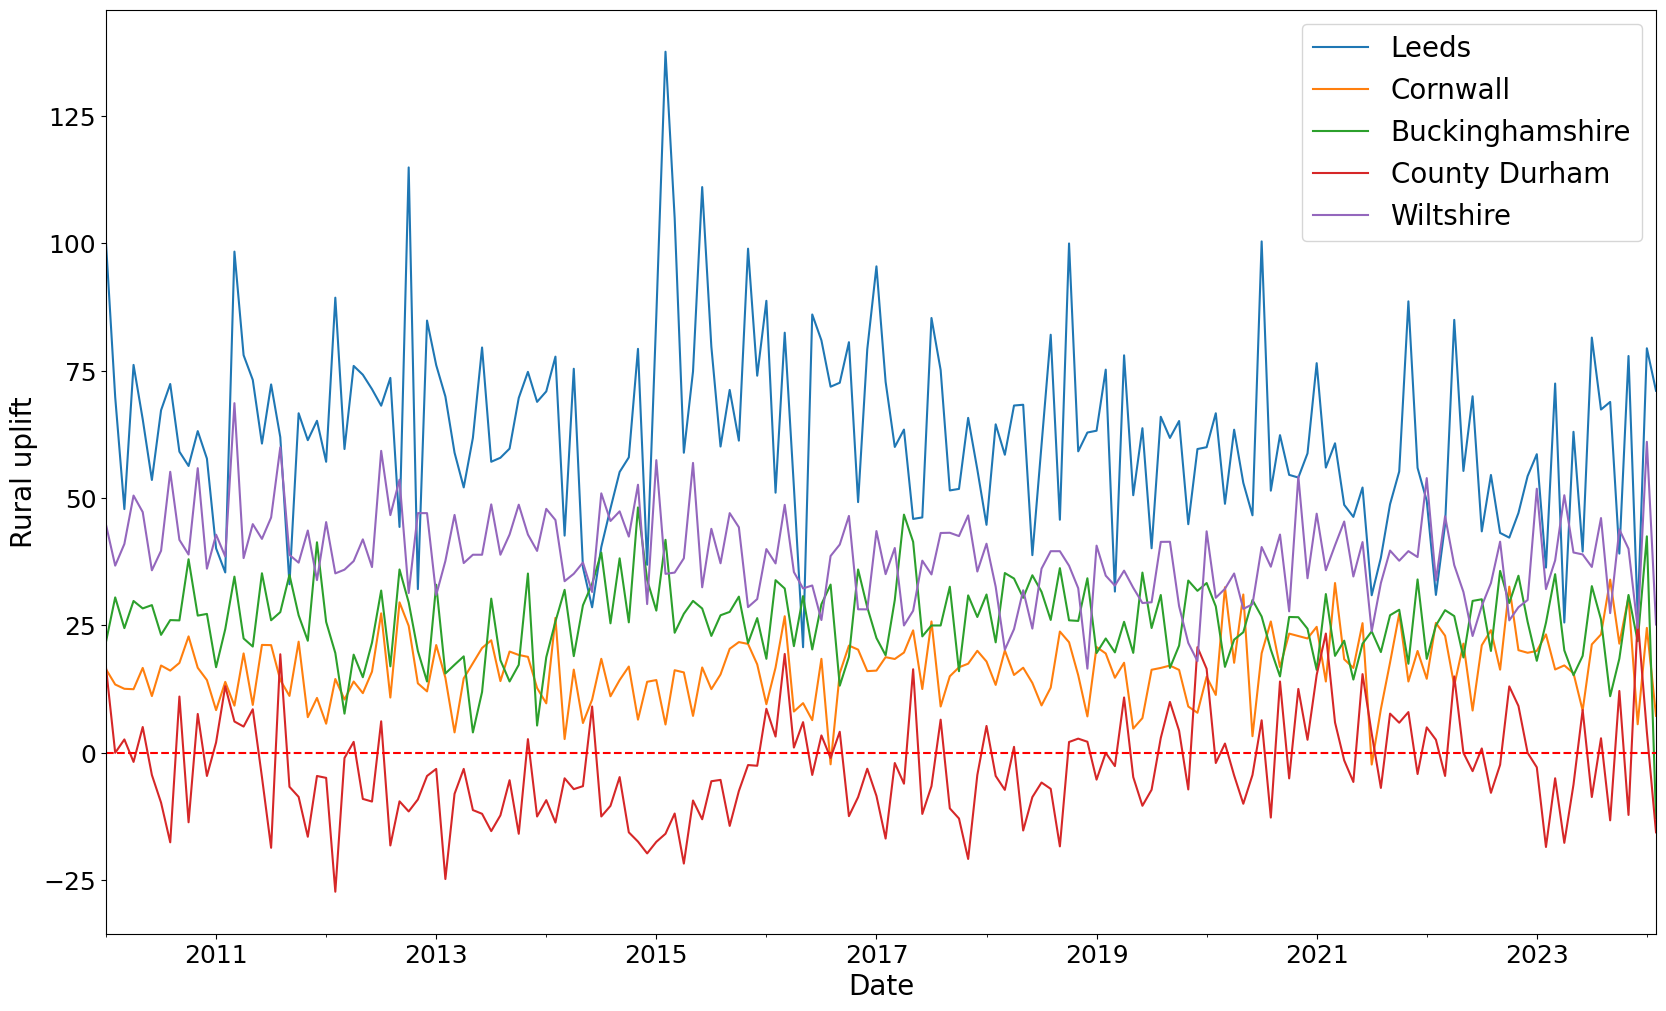

In [38]:
fig, ax = plt.subplots(figsize=(20,12))
i = 0
for lad in smaller[smaller.datey >= '2010-01-01'].groupby('LAD22NM').size().sort_values(ascending=False).head(6).index:
    if lad == 'Birmingham':
        i += 1
        continue
    frame = smaller[(smaller.LAD22NM == lad) & (smaller.datey >= '2010-01-01')]
    urban = frame[frame.urb_rur == 'Urban']
    a = urban.groupby('month_year').price.median().reset_index()
    a.columns = ['month_year', 'avg_price']
    rural = frame[frame.urb_rur == 'Rural']
    b = rural.groupby('month_year').price.median().reset_index()
    b.columns = ['month_year', 'avg_price']
    merge_thing = a.merge(b, how='inner', on='month_year', suffixes=('_urban', '_rural'))
    merge_thing.loc[:, 'pct_thing'] = ((merge_thing.avg_price_rural / merge_thing.avg_price_urban)*100)-100
    merge_thing.plot(ax=ax, x='month_year', y='pct_thing', label=lad)
    i += 1

plt.legend(fontsize=20)
plt.axhline(y=0, ls='dashed', color='red')
plt.xlabel('Date', fontsize=20)
plt.ylabel('Rural uplift', fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.show()

In [39]:
smaller.head()

,Unnamed: 0,id,price,date,postcode,property_type,old_new,duration,paon,saon,...,y_coord,lat,lon,OA11CD,LAD22NM,RUC11CD,RUC11,datey,month_year,urb_rur
0,0,{8524B47D-47ED-4C6B-97BF-D114570165DE},56950,1995-10-20 00:00,ST5 7UE,D,Y,F,2,NaN,...,350560.34,53.052039,-2.257366,E00150541,Newcastle-under-Lyme,C1,Urban city and town,1995-10-20,1995-10,Urban
1,1,{92A77299-BCFF-433B-B54D-D114861197D7},56952,1995-03-31 00:00,SE16 3EY,F,Y,L,3,FLAT 27,...,178381.00,51.488331,-0.060520,E00020342,Southwark,A1,Urban major conurbation,1995-03-31,1995-03,Urban
2,2,{AECA5453-F149-46BF-B3E3-CA05B7E47CE5},74000,1995-12-01 00:00,DY8 5PW,D,N,F,66,NaN,...,287130.00,52.481988,-2.167445,E00050170,Dudley,A1,Urban major conurbation,1995-12-01,1995-12,Urban
3,3,{6785BDEE-16CA-4D80-8131-CA05D4F4DBE0},155000,1995-08-09 00:00,OX39 4AF,D,Y,F,THE PANTILES,NaN,...,202835.00,51.719093,-0.899908,E00145755,South Oxfordshire,F1,Rural hamlets and isolated dwellings,1995-08-09,1995-08,Rural
4,4,{3FAA4BB3-40B8-4003-8C5B-D494636C6410},75000,1995-09-08 00:00,SN9 5HD,D,N,F,6,NaN,...,160302.00,51.341568,-1.766247,E00162545,Wiltshire,D1,Rural town and fringe,1995-09-08,1995-09,Rural


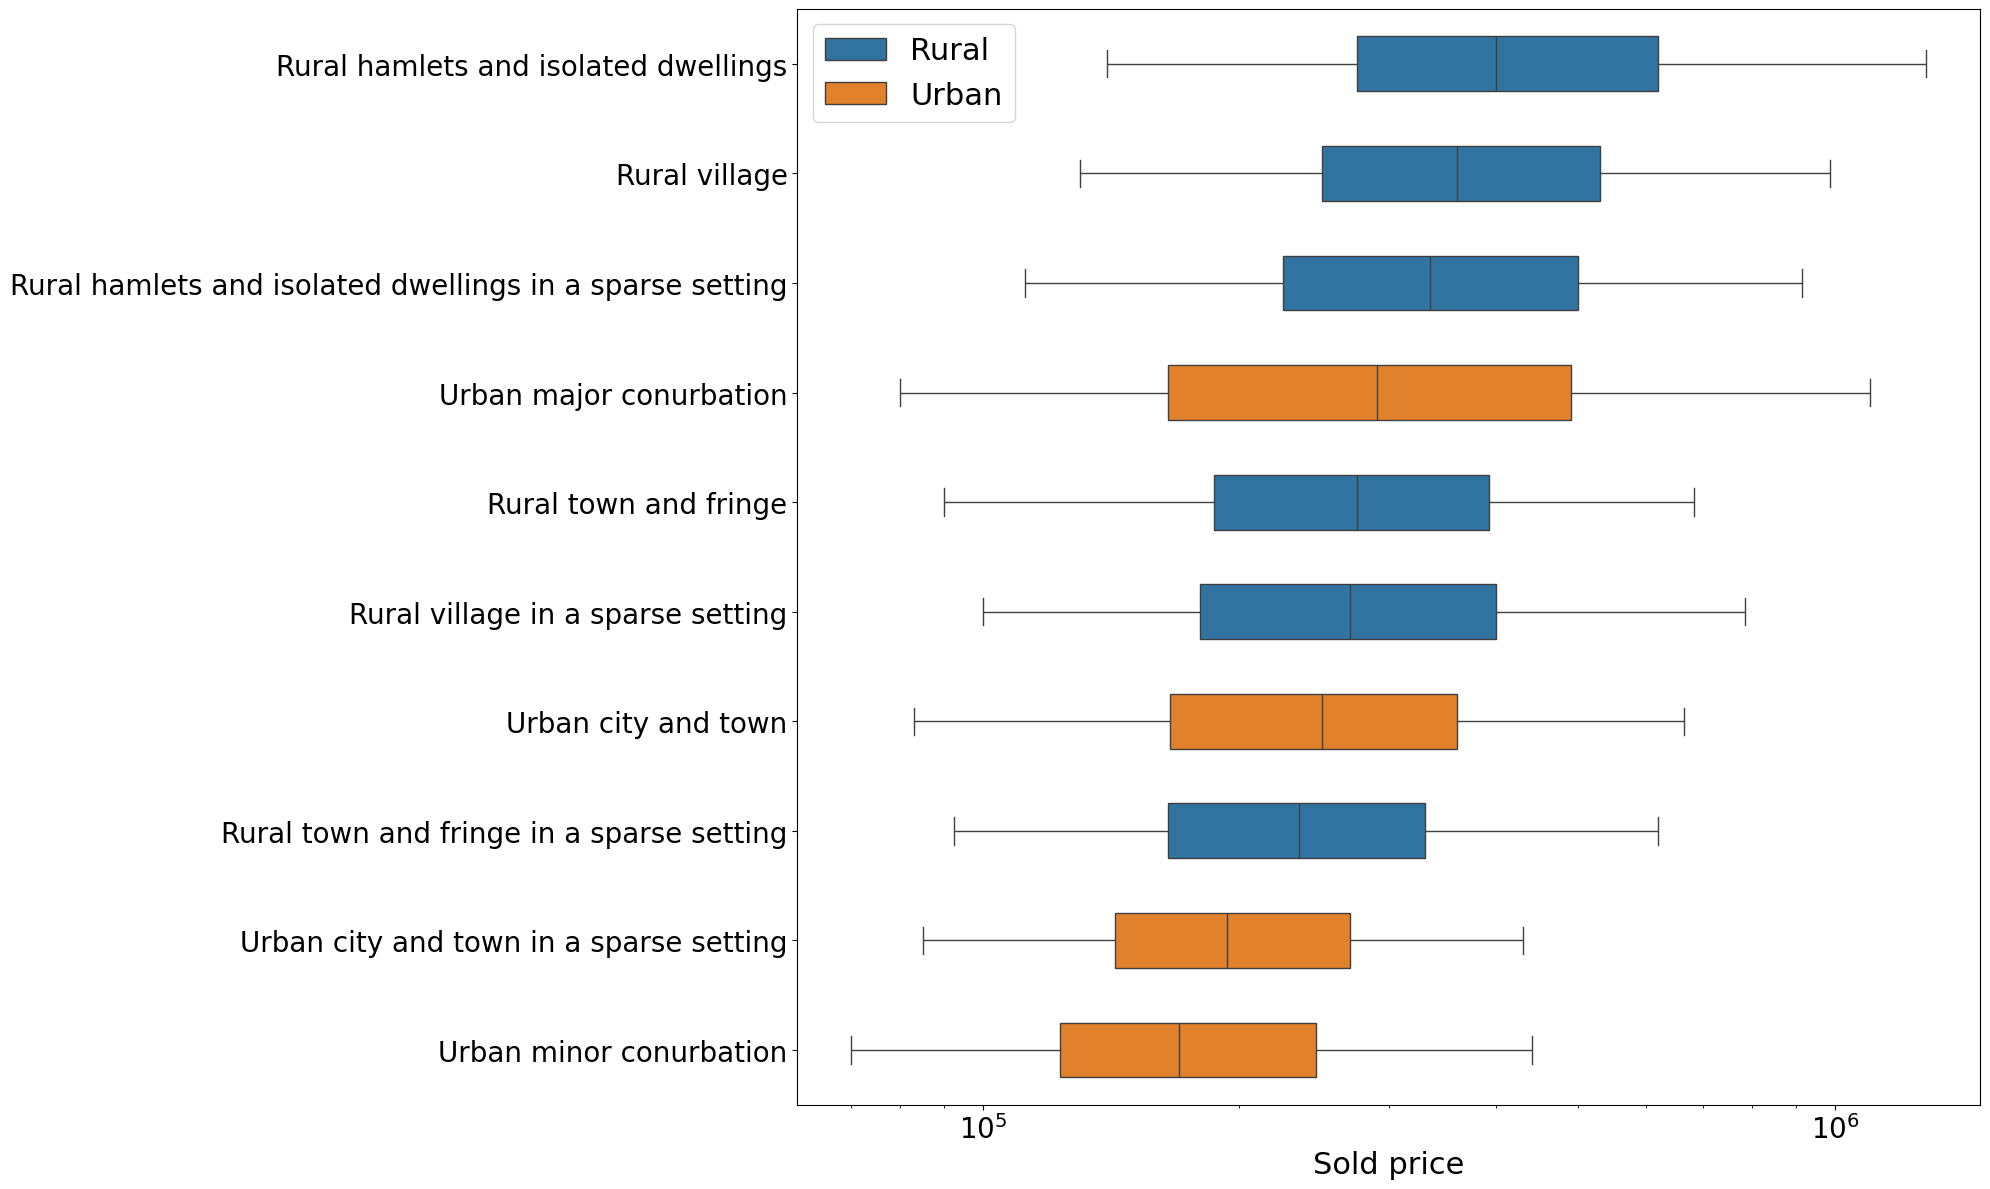

In [41]:
fig, ax = plt.subplots(figsize=(20,12))
sns.boxplot(data=smaller[smaller.datey >= '2020-01-01'], x="price", y="RUC11", whis=[5,95], log_scale=True, width=.5, ax=ax, showfliers=False, hue='urb_rur', order=med)
plt.xlabel('Sold price', fontsize=22)
plt.xticks(fontsize=20)
plt.ylabel('')
plt.yticks(fontsize=20, rotation=0)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels)
plt.legend(fontsize=22)

plt.tight_layout()
plt.savefig('../results/2020_sale_price_by_type.png')
plt.show()

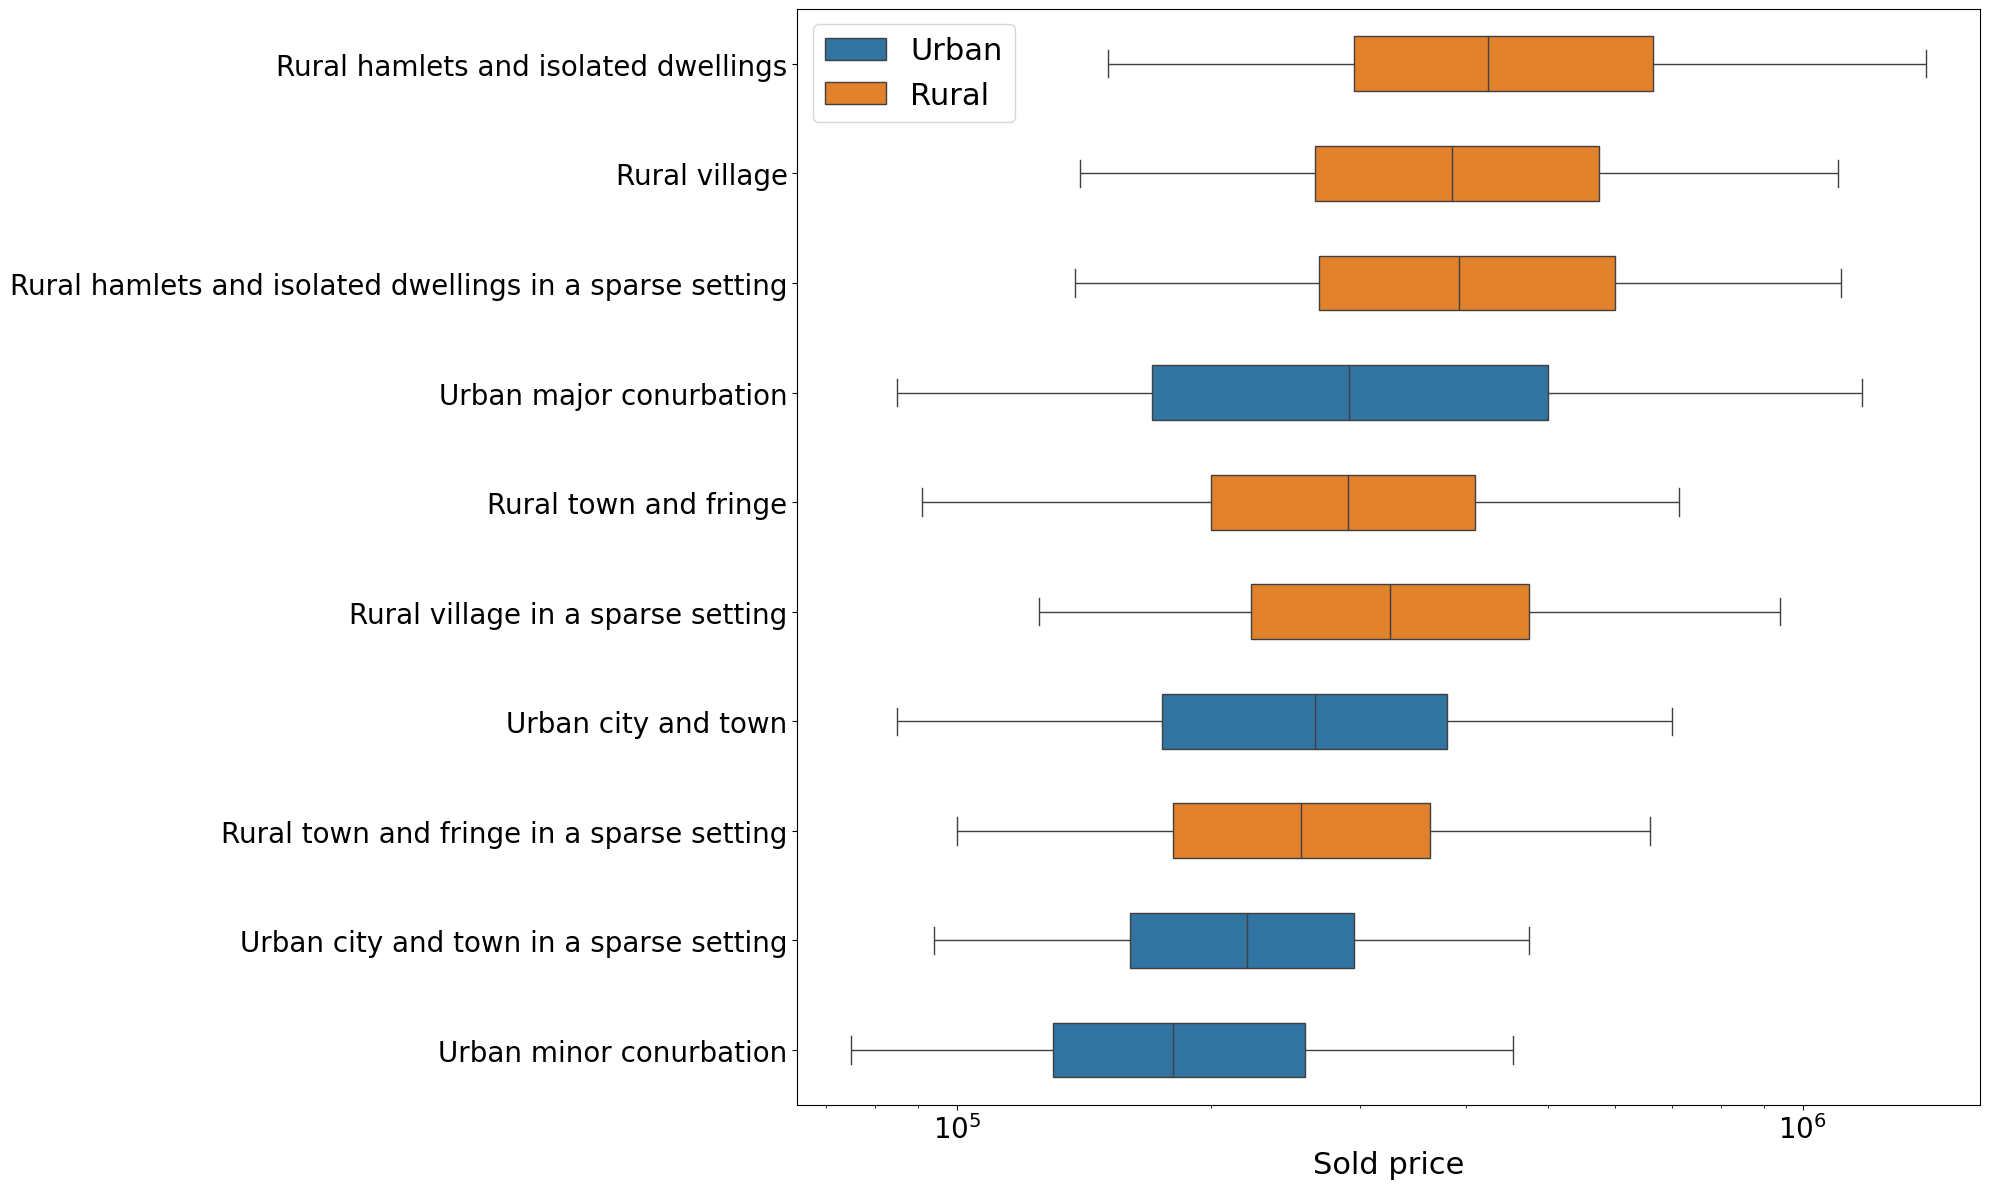

In [42]:
fig, ax = plt.subplots(figsize=(20,12))
sns.boxplot(data=smaller[smaller.datey >= '2022-01-01'], x="price", y="RUC11", whis=[5,95], log_scale=True, width=.5, ax=ax, showfliers=False, hue='urb_rur', order=med)
plt.xlabel('Sold price', fontsize=22)
plt.xticks(fontsize=20)
plt.ylabel('')
plt.yticks(fontsize=20, rotation=0)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels)
plt.legend(fontsize=22)

plt.tight_layout()
plt.savefig('../results/2022_sale_price_by_type.png')
plt.show()

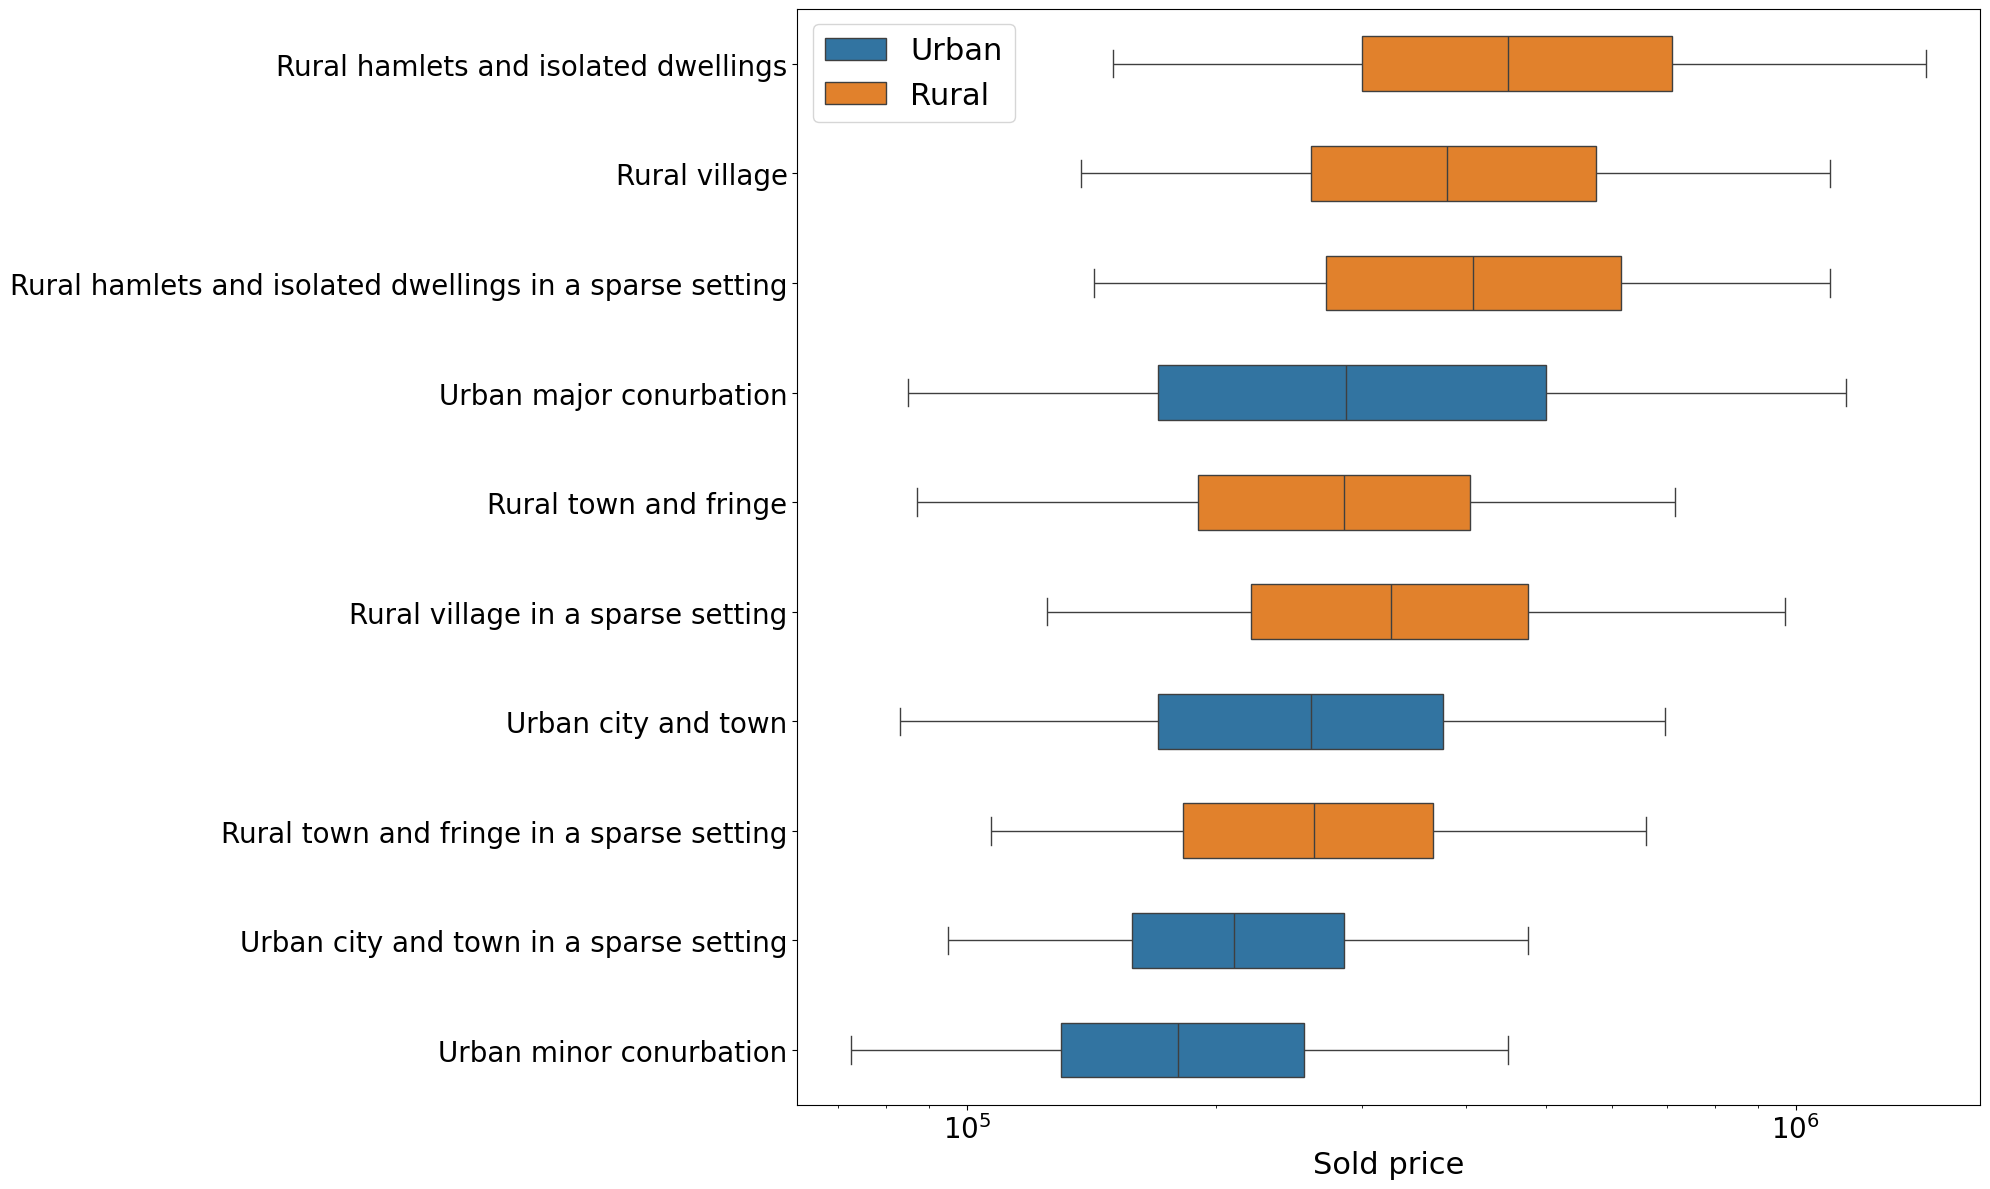

In [43]:
fig, ax = plt.subplots(figsize=(20,12))
sns.boxplot(data=smaller[smaller.datey >= '2023-01-01'], x="price", y="RUC11", whis=[5,95], log_scale=True, width=.5, ax=ax, showfliers=False, hue='urb_rur', order=med)
plt.xlabel('Sold price', fontsize=22)
plt.xticks(fontsize=20)
plt.ylabel('')
plt.yticks(fontsize=20, rotation=0)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels)
plt.legend(fontsize=22)

plt.tight_layout()
plt.savefig('../results/2023_sale_price_by_type.png')
plt.show()

In [44]:
smaller.head()

,Unnamed: 0,id,price,date,postcode,property_type,old_new,duration,paon,saon,...,y_coord,lat,lon,OA11CD,LAD22NM,RUC11CD,RUC11,datey,month_year,urb_rur
0,0,{8524B47D-47ED-4C6B-97BF-D114570165DE},56950,1995-10-20 00:00,ST5 7UE,D,Y,F,2,NaN,...,350560.34,53.052039,-2.257366,E00150541,Newcastle-under-Lyme,C1,Urban city and town,1995-10-20,1995-10,Urban
1,1,{92A77299-BCFF-433B-B54D-D114861197D7},56952,1995-03-31 00:00,SE16 3EY,F,Y,L,3,FLAT 27,...,178381.00,51.488331,-0.060520,E00020342,Southwark,A1,Urban major conurbation,1995-03-31,1995-03,Urban
2,2,{AECA5453-F149-46BF-B3E3-CA05B7E47CE5},74000,1995-12-01 00:00,DY8 5PW,D,N,F,66,NaN,...,287130.00,52.481988,-2.167445,E00050170,Dudley,A1,Urban major conurbation,1995-12-01,1995-12,Urban
3,3,{6785BDEE-16CA-4D80-8131-CA05D4F4DBE0},155000,1995-08-09 00:00,OX39 4AF,D,Y,F,THE PANTILES,NaN,...,202835.00,51.719093,-0.899908,E00145755,South Oxfordshire,F1,Rural hamlets and isolated dwellings,1995-08-09,1995-08,Rural
4,4,{3FAA4BB3-40B8-4003-8C5B-D494636C6410},75000,1995-09-08 00:00,SN9 5HD,D,N,F,6,NaN,...,160302.00,51.341568,-1.766247,E00162545,Wiltshire,D1,Rural town and fringe,1995-09-08,1995-09,Rural


In [45]:
avg_prices_per_lad = smaller.groupby('LAD22NM').apply(lambda x: x.sort_values(by='datey').groupby('month_year').price.mean()).reset_index()
avg_prices_per_lad.head(10)

/var/folders/jr/scz17gjs3zd226jcsn8k38480000gn/T/ipykernel_24351/487686631.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  avg_prices_per_lad = smaller.groupby('LAD22NM').apply(lambda x: x.sort_values(by='datey').groupby('month_year').price.mean()).reset_index()


,LAD22NM,month_year,price
0,Adur,1995-01,56729.168831
1,Adur,1995-02,55134.347826
2,Adur,1995-03,58356.446602
3,Adur,1995-04,60931.607143
4,Adur,1995-05,61341.868421
5,Adur,1995-06,62248.280374
6,Adur,1995-07,57924.790909
7,Adur,1995-08,56391.666667
8,Adur,1995-09,60176.709302
9,Adur,1995-10,54968.917526


In [46]:
avg_prices_per_lad.loc[:, 'pct_annual_change'] = avg_prices_per_lad.groupby('LAD22NM').price.pct_change(periods=12)*100
avg_prices_per_lad.tail()

,LAD22NM,month_year,price,pct_annual_change
115193,York,2023-10,368607.658537,-1.620423
115194,York,2023-11,313783.692308,-23.305795
115195,York,2023-12,330995.500000,-11.653194
115196,York,2024-01,370988.888889,9.753227
115197,York,2024-02,341615.384615,-0.681860


In [47]:
biggest_lads = smaller.groupby('LAD22NM').size().sort_values(ascending=False).head(20).index.values
biggest_lads

array(['Birmingham', 'Leeds', 'Cornwall', 'Buckinghamshire', 'Wiltshire',
       'County Durham', 'Bradford', 'Bournemouth, Christchurch and Poole',
       'West Northamptonshire', 'Sheffield', 'Manchester', 'Bristol',
       'Cheshire East', 'Dorset', 'East Riding of Yorkshire', 'Kirklees',
       'Liverpool', 'North Northamptonshire', 'Cheshire West and Chester',
       'Wandsworth'], dtype=object)

In [48]:
pd.plotting.register_matplotlib_converters()

In [49]:
national_average = smaller.groupby('month_year').price.mean().reset_index()
national_average.loc[:, 'pct_annual_change'] = national_average.price.pct_change(periods=12)*100
national_average.tail()

,month_year,price,pct_annual_change
345,2023-10,368825.109266,-4.962847
346,2023-11,358905.755419,-8.983270
347,2023-12,339579.219245,-12.358839
348,2024-01,339499.395981,-11.176350
349,2024-02,326629.330969,-8.905042


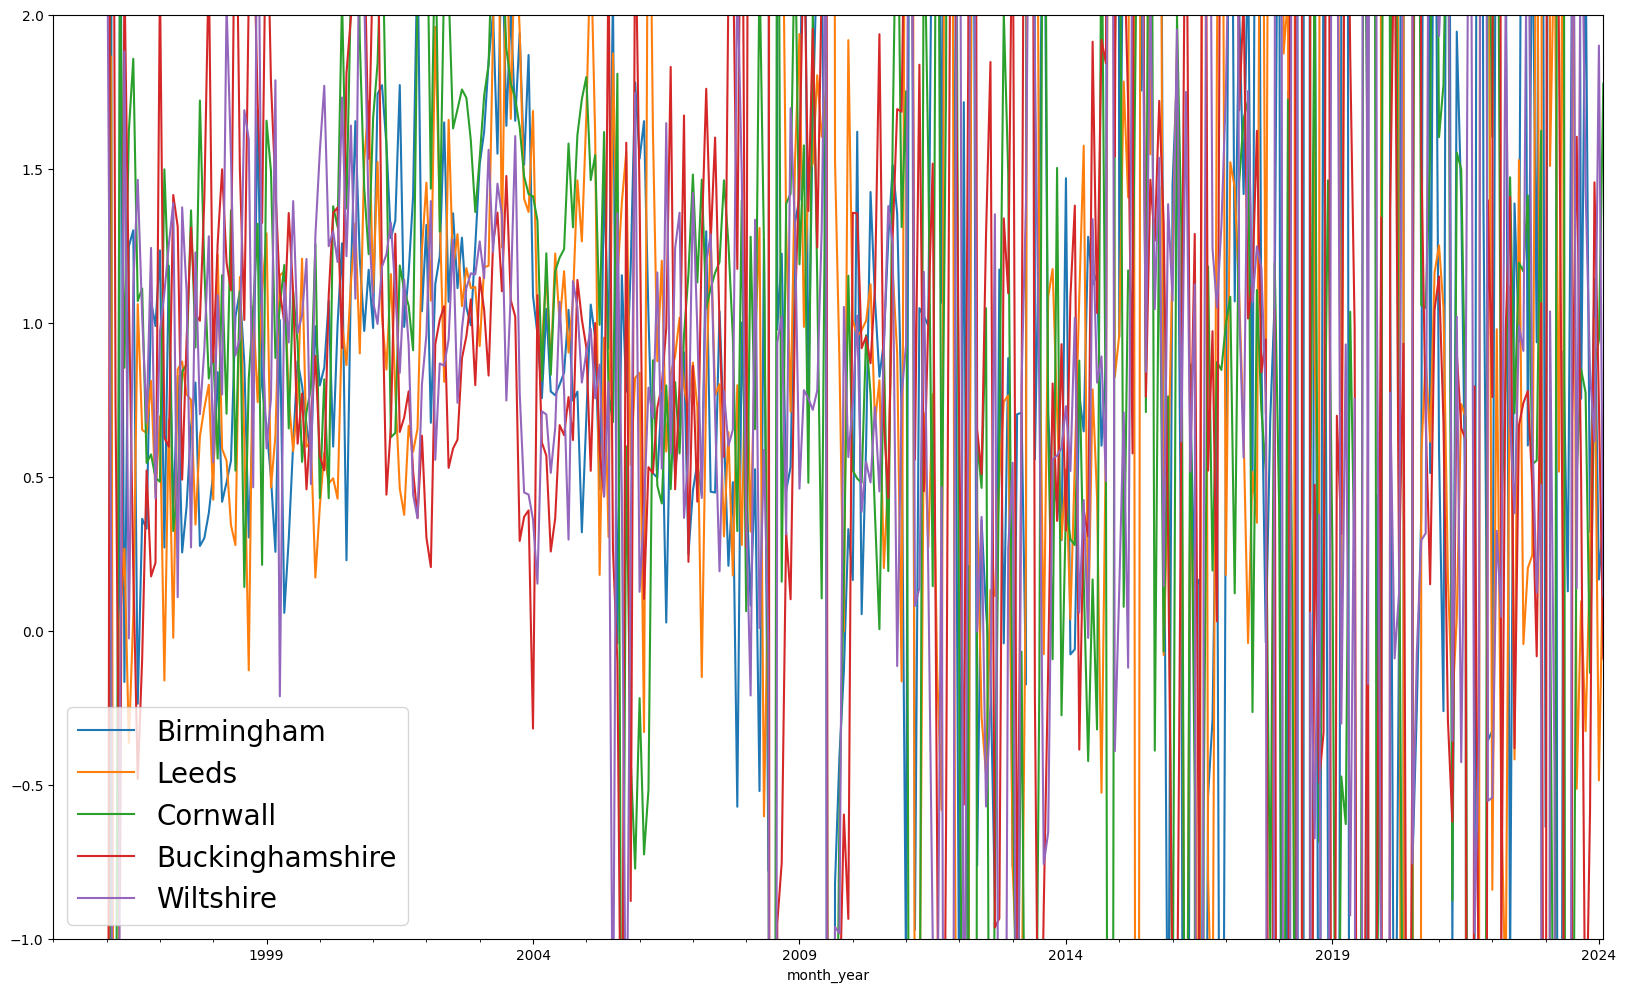

In [50]:
fig, ax = plt.subplots(figsize=(20,12))
for lad in biggest_lads[:5]:
    f = avg_prices_per_lad[avg_prices_per_lad.LAD22NM == lad]
    f_merge = f.merge(national_average, how='inner', on='month_year', suffixes=('', '_national'))
    f_merge.loc[:, 'pct_diff'] = f_merge.pct_annual_change / f_merge.pct_annual_change_national
    f_merge.plot(ax=ax, x='month_year', y='pct_diff', label=lad)

plt.ylim([-1,2])
plt.legend(fontsize=20)
plt.show()

In [51]:
f_merge.head()

,LAD22NM,month_year,price,pct_annual_change,price_national,pct_annual_change_national,pct_diff
0,Wiltshire,1995-01,76798.923077,NaN,67577.859920,NaN,NaN
1,Wiltshire,1995-02,69457.591337,NaN,65210.276918,NaN,NaN
2,Wiltshire,1995-03,73942.058120,NaN,65348.355676,NaN,NaN
3,Wiltshire,1995-04,73336.160714,NaN,67263.382551,NaN,NaN
4,Wiltshire,1995-05,74472.111667,NaN,66577.104299,NaN,NaN


In [52]:
import ruptures as rpt

In [63]:
rural_sales = smaller[smaller.urb_rur == 'Rural']
urban_sales = smaller[smaller.urb_rur == 'Urban']
grouped_rural = rural_sales.groupby('month_year').price.median().reset_index()
grouped_urban = urban_sales.groupby('month_year').price.median().reset_index()

merged_median_prices = grouped_rural.merge(grouped_urban, how='inner', on='month_year', suffixes=('_rural', '_urban'))
merged_median_prices.head()

,month_year,price_rural,price_urban
0,1995-01,60000.0,52000.0
1,1995-02,59995.0,52000.0
2,1995-03,59650.0,52000.0
3,1995-04,61000.0,52950.0
4,1995-05,60000.0,52995.0


In [65]:
merged_median_prices.loc[:, 'pct_rural_uplift'] = 100*((merged_median_prices.price_rural / merged_median_prices.price_urban) - 1)
merged_median_prices.head()

,month_year,price_rural,price_urban,pct_rural_uplift
0,1995-01,60000.0,52000.0,15.384615
1,1995-02,59995.0,52000.0,15.375000
2,1995-03,59650.0,52000.0,14.711538
3,1995-04,61000.0,52950.0,15.203022
4,1995-05,60000.0,52995.0,13.218228


In [66]:
mini = merged_median_prices[['month_year', 'pct_rural_uplift']].set_index('month_year')
mini.head()

,pct_rural_uplift
month_year,
1995-01,15.384615
1995-02,15.375000
1995-03,14.711538
1995-04,15.203022
1995-05,13.218228


In [109]:
rpt.Pelt?

Init signature: rpt.Pelt(model='l2', custom_cost=None, min_size=2, jump=5, params=None)
Docstring:     
Penalized change point detection.

For a given model and penalty level, computes the segmentation which
minimizes the constrained sum of approximation errors.
Init docstring:
Initialize a Pelt instance.

Args:
    model (str, optional): segment model, ["l1", "l2", "rbf"]. Not used if ``'custom_cost'`` is not None.
    custom_cost (BaseCost, optional): custom cost function. Defaults to None.
    min_size (int, optional): minimum segment length.
    jump (int, optional): subsample (one every *jump* points).
    params (dict, optional): a dictionary of parameters for the cost instance.
File:           /opt/homebrew/lib/python3.12/site-packages/ruptures/detection/pelt.py
Type:           ABCMeta
Subclasses:     

(<Figure size 1000x200 with 1 Axes>, [<Axes: >])

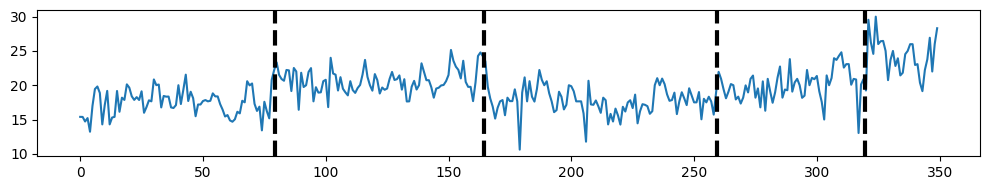

In [117]:
algo = rpt.Pelt(model="l2", min_size=2)
algo.fit(mini)
result = algo.predict(pen=80)
rpt.display(mini, [], result)

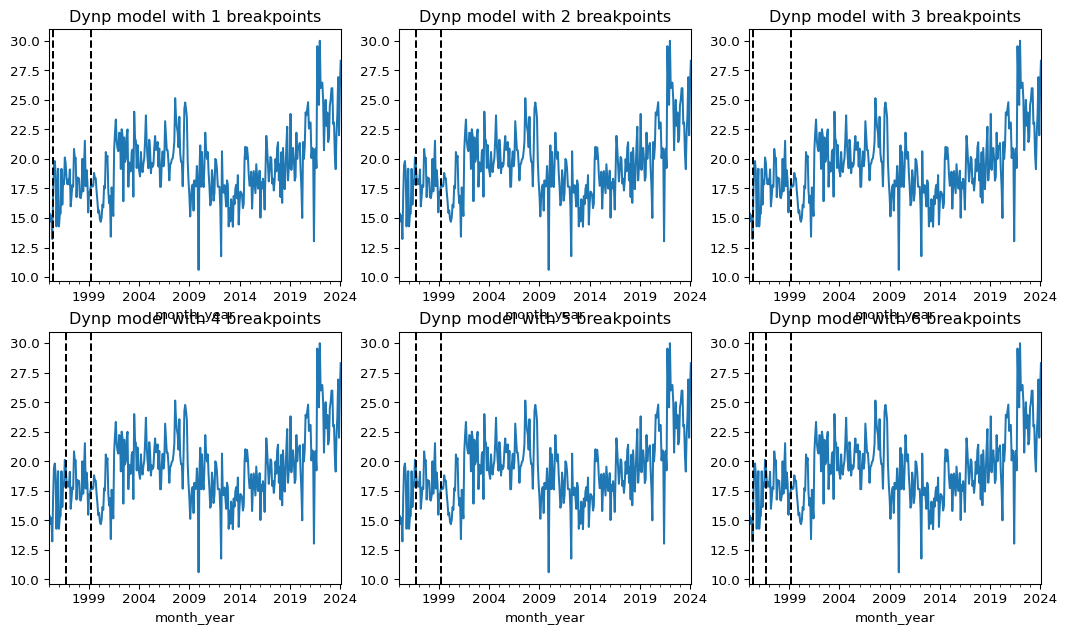

In [79]:
fig, ax = plt.subplots(2,3, figsize=(1280/96, 720/96), dpi=96)
ax = ax.ravel()

algo = rpt.Dynp(model="l2", min_size=1)
algo.fit(mini)

for i, n_bkps in enumerate([1, 2, 3, 4, 5, 6]):
    result = algo.predict(n_bkps=n_bkps)
    mini.plot(ax=ax[i], legend=None)
#    ax[i].plot(mini)
    for bkp in result:
        ax[i].axvline(x=bkp, color='k', linestyle='--')
    ax[i].set_title(f"Dynp model with {n_bkps} breakpoints")

(<Figure size 1000x200 with 1 Axes>, [<Axes: >])

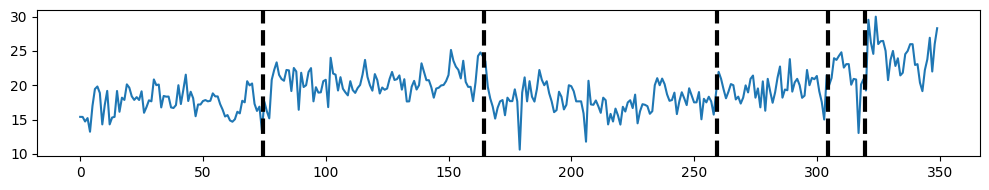

In [81]:
algo = rpt.Binseg(model="l2", min_size=3)
algo.fit(mini)
result = algo.predict(n_bkps=5)
rpt.display(mini, [], result)

(<Figure size 1000x200 with 1 Axes>, [<Axes: >])

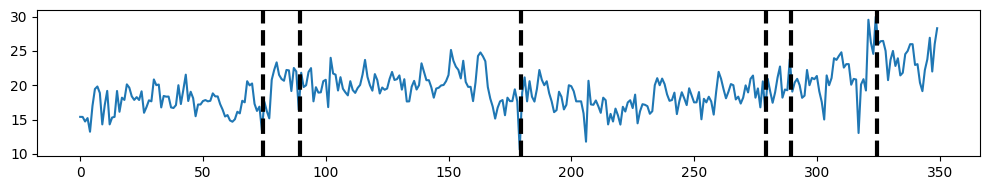

In [84]:
algo = rpt.Window(model="l2", width=3)
algo.fit(mini)
result = algo.predict(n_bkps=6)
rpt.display(mini, [], result)

(<Figure size 1000x200 with 1 Axes>, [<Axes: >])

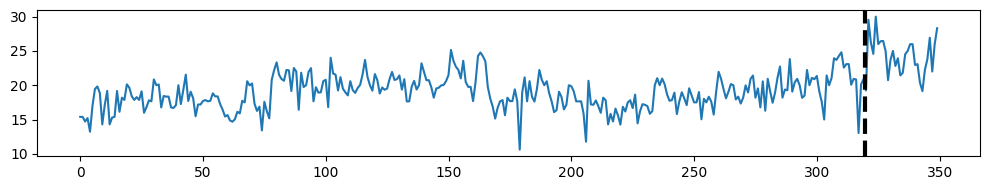

In [90]:
algo = rpt.BottomUp(model="l2", min_size=1)
algo.fit(mini)
result = algo.predict(n_bkps=1)
rpt.display(mini, [], result)

In [91]:
result

[320, 350]

In [93]:
result_location = []
for i in range(10):
    algo = rpt.BottomUp(model="l2", min_size=1)
    algo.fit(mini)
    result = algo.predict(n_bkps=i)
    result_location.append(result)
    algo = rpt.Window(model="l2", width=2)
    algo.fit(mini)
    result = algo.predict(n_bkps=i)
    result_location.append(result)
    algo = rpt.Binseg(model="l2", min_size=1)
    algo.fit(mini)
    result = algo.predict(n_bkps=i)
    result_location.append(result)
    algo = rpt.Pelt(model="l2", min_size=1)
    algo.fit(mini)
    result = algo.predict(pen=i)
    result_location.append(result)
    

In [118]:
result_location[:5]

[[350],
 [350],
 [350],
 [5,
  10,
  15,
  25,
  30,
  35,
  40,
  45,
  60,
  65,
  70,
  80,
  85,
  95,
  100,
  105,
  115,
  120,
  125,
  130,
  135,
  145,
  150,
  155,
  165,
  180,
  190,
  205,
  215,
  220,
  235,
  240,
  245,
  250,
  260,
  265,
  270,
  275,
  280,
  305,
  315,
  320,
  330,
  335,
  340,
  345,
  350],
 [320, 350]]

In [98]:
all_results = [item for sublist in result_location for item in sublist]
from collections import Counter
a = Counter(all_results)
a.most_common(10)

[(350, 40),
 (165, 24),
 (320, 24),
 (260, 22),
 (305, 21),
 (5, 20),
 (180, 19),
 (80, 18),
 (150, 14),
 (340, 14)]

In [99]:
len(result_location)

40

In [102]:
a.get(304,0)

0

In [103]:
density = []
for x in range(350):
    density.append(a.get(x,0)/40)
    

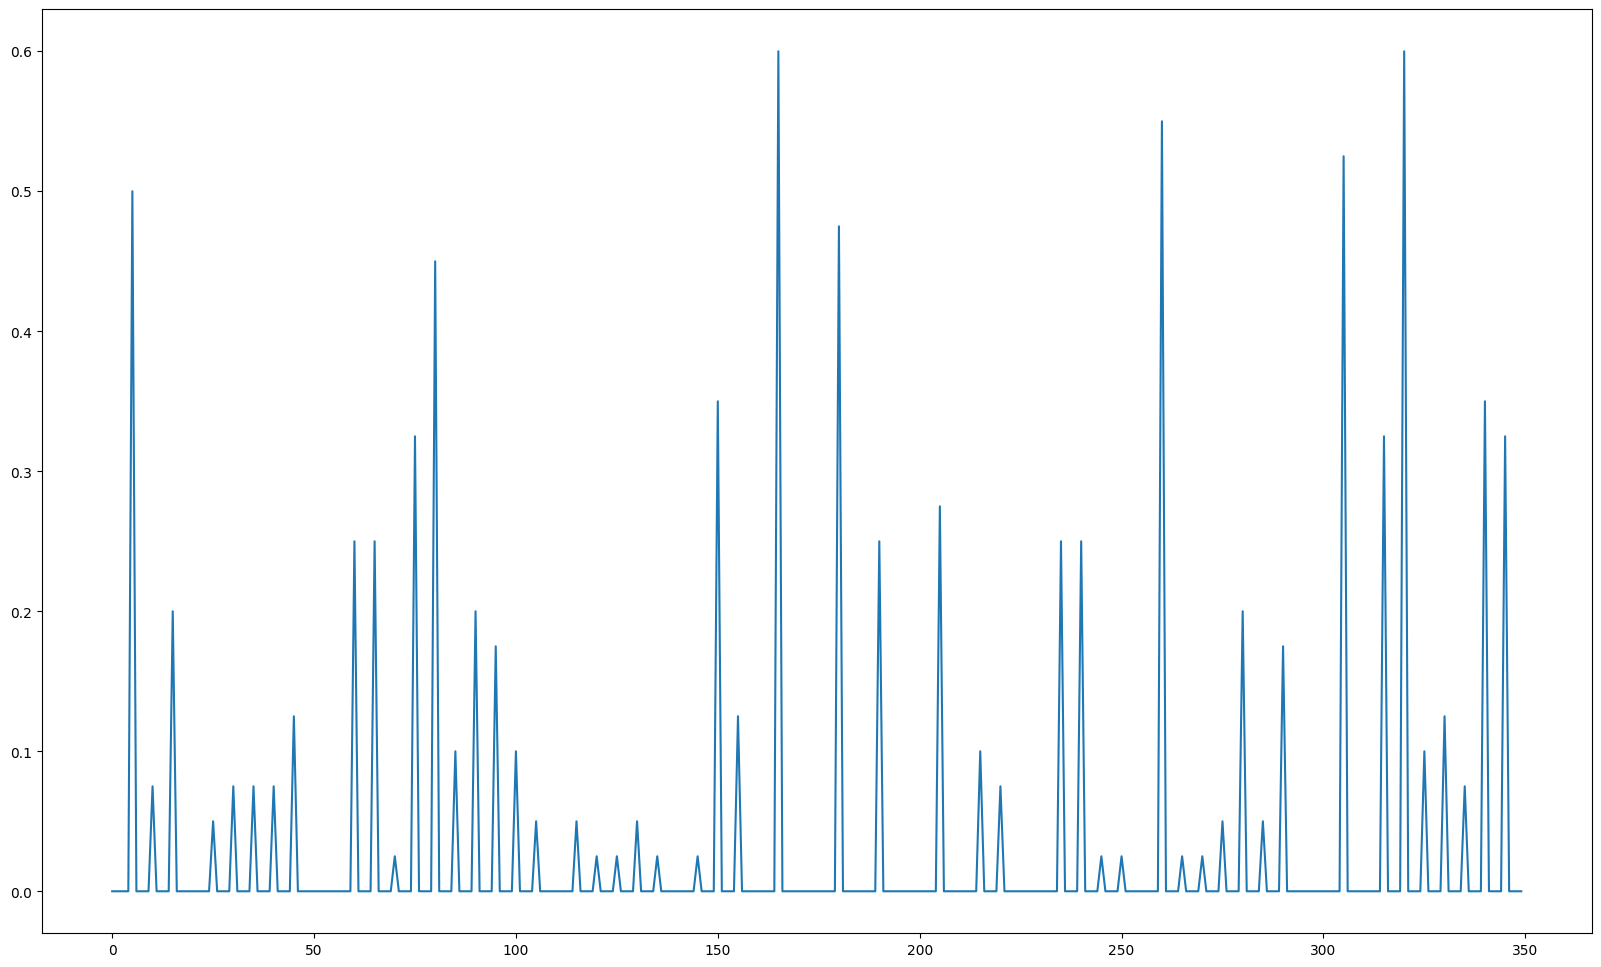

In [106]:
fig, ax = plt.subplots(figsize=(20,12))
plt.plot(np.arange(len(density)), density)
plt.show()

## Which bits

In [123]:
most_rural = smaller.groupby('LAD22NM').apply(lambda x: (x[x.urb_rur == 'Rural'].shape[0]/x.shape[0], x.shape[0])).reset_index()
most_rural.head()

/var/folders/jr/scz17gjs3zd226jcsn8k38480000gn/T/ipykernel_24351/985005068.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  most_rural = smaller.groupby('LAD22NM').apply(lambda x: (x[x.urb_rur == 'Rural'].shape[0]/x.shape[0], x.shape[0])).reset_index()


,LAD22NM,0
0,Adur,"(0.005808183993929134, 34262)"
1,Allerdale,"(0.7298339328408039, 46427)"
2,Amber Valley,"(0.18115388143210934, 65414)"
3,Arun,"(0.1514370039256139, 104697)"
4,Ashfield,"(0.006587679259331197, 61782)"


In [129]:
most_rural.columns = ['LAD22NM', 'thingy']
ah = most_rural.thingy.apply(pd.Series, index=['pct_rural', 'num_sales'])
most_rural = most_rural[['LAD22NM']].join(ah)
most_rural.sort_values(by='pct_rural', ascending=False).head(25)

,LAD22NM,pct_rural,num_sales
144,Isles of Scilly,1.000000,533.0
220,Richmondshire,0.877822,22410.0
117,Gwynedd,0.877192,45616.0
192,North Norfolk,0.872822,61591.0
210,Powys,0.870741,44291.0
142,Isle of Anglesey,0.842064,26878.0
54,Ceredigion,0.801538,23803.0
120,Hambleton,0.797299,43759.0
69,Cotswold,0.794602,47094.0
205,Pembrokeshire,0.777983,47028.0


In [130]:
most_rural.sort_values(by='num_sales', ascending=False).head(25)

,LAD22NM,pct_rural,num_sales
17,Birmingham,0.000477,413202.0
154,Leeds,0.062132,376583.0
68,Cornwall,0.599959,301844.0
40,Buckinghamshire,0.303900,273458.0
317,Wiltshire,0.394898,254139.0
70,County Durham,0.457250,251987.0
27,Bradford,0.085437,245937.0
25,"Bournemouth, Christchurch and Poole",0.001667,245933.0
312,West Northamptonshire,0.294621,231131.0
239,Sheffield,0.019729,230062.0


## Pretty Figures

In [18]:
urban = smaller[smaller.urb_rur == 'Urban'].groupby('month_year')
rural = smaller[smaller.urb_rur == 'Rural'].groupby('month_year')

AttributeError: 'DataFrame' object has no attribute 'urb_rur'

In [15]:
import matplotlib.transforms as mtransforms
import matplotlib as mpl

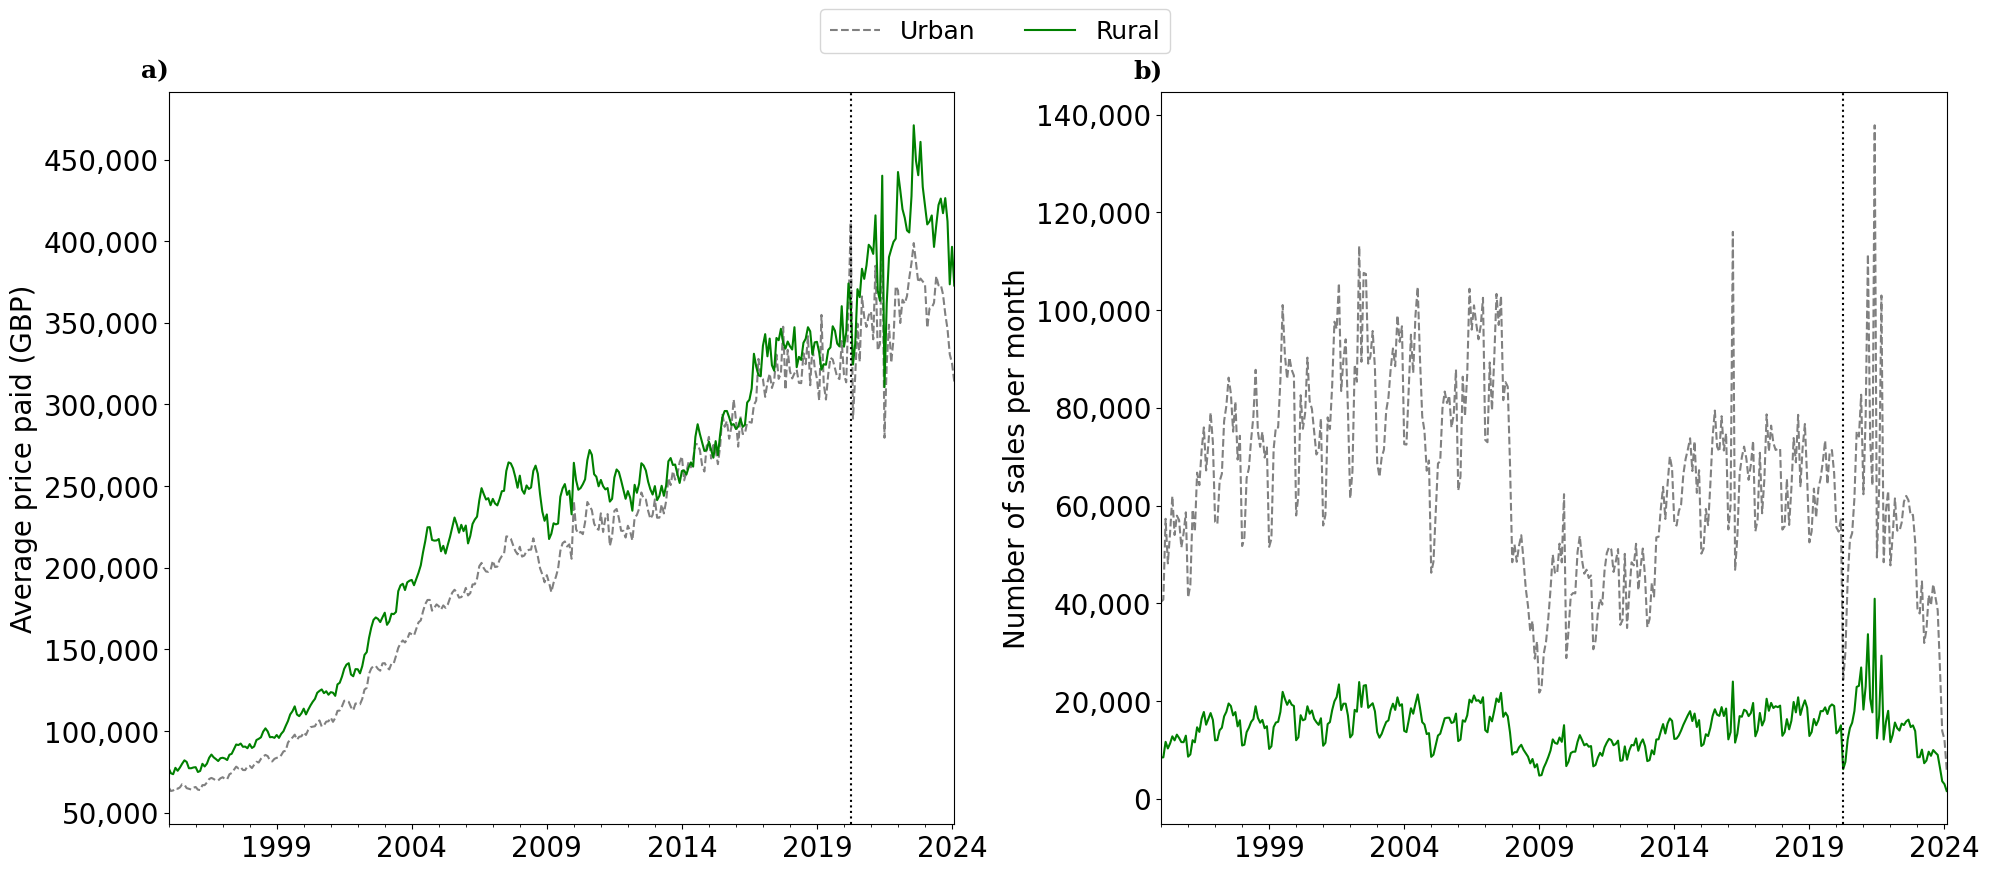

In [191]:



fig, axs = plt.subplots(1,2,figsize=(20,8), sharex=True)
flat_ax = axs.flat

## num sales
urban.price.mean().plot(ax=flat_ax[0], label='Urban', color='grey', ls='dashed', legend=None, fontsize=20)
rural.price.mean().plot(ax=flat_ax[0], label='Rural', color='green', ls='solid', legend=None , fontsize=20)
flat_ax[0].yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
#flat_ax[0].tick_params(axis='both', labelsize=18)
flat_ax[0].set_xlabel('')
flat_ax[0].set_ylabel('Average price paid (GBP)', fontsize=20)
flat_ax[0].axvline(x='2020-04', ls='dotted', color='k')


## num sales
urban.price.size().plot(ax=flat_ax[1], label='Urban', color='grey', ls='dashed', legend=None, fontsize=20)
rural.price.size().plot(ax=flat_ax[1], label='Rural', color='green', ls='solid', legend=None , fontsize=20)
flat_ax[1].yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
#flat_ax[0].tick_params(axis='both', labelsize=18)
flat_ax[1].set_xlabel('')
flat_ax[1].set_ylabel('Number of sales per month', fontsize=20)
flat_ax[1].axvline(x='2020-04', ls='dotted', color='k')

handles, labels = flat_ax[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, fontsize=18, bbox_to_anchor = (0, 0.1, 1, 1), frameon=True, fancybox=True)
plt.tight_layout()

for label, ax in zip(['a)', 'b)'], flat_ax):
    # label physical distance to the left and up:
    trans = mtransforms.ScaledTranslation(-20/72, 7/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, label, transform=ax.transAxes + trans,
            fontsize=18, va='bottom', fontfamily='serif', weight='bold')

plt.savefig('../results/raw_numbers_urban_rural_split.png', dpi=300, bbox_inches='tight')

plt.show()


# fig, ax = plt.subplots(figsize=(20,12))
# rural = smaller[smaller.urb_rur == 'Rural']
# rural = rural.groupby('month_year').price.mean().reset_index()
# rural.columns = ['month_year', 'avg_price_base']

# rural.plot(ax=ax, x='month_year', y='avg_price_base', label='Rural')
# base.plot(ax=ax, x='month_year', y='avg_price_base', label='Urban')
# ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
# plt.legend(fontsize=20)
# plt.xlabel('Date', fontsize=22)
# plt.xticks(fontsize=20)
# plt.ylabel('Average price (GBP)', fontsize=22)
# plt.yticks(fontsize=20)
# plt.tight_layout()
# plt.savefig('../results/avg_price_over_time.png', dpi=300, bbox_inches='tight')
# plt.show()

In [169]:
100*((rural.price.mean() / urban.price.mean()) - 1)

month_year
1995-01    17.925732
1995-02    17.164523
1995-03    15.630960
1995-04    19.142019
1995-05    17.071837
             ...    
2023-10    19.975344
2023-11    19.048621
2023-12    12.959789
2024-01    21.920169
2024-02    18.748920
Freq: M, Name: price, Length: 350, dtype: float64

In [172]:
rural.size() / urban.size()

month_year
1995-01    0.209873
1995-02    0.209068
1995-03    0.204009
1995-04    0.214490
1995-05    0.208555
             ...   
2023-10    0.233700
2023-11    0.239374
2023-12    0.260835
2024-01    0.249528
2024-02    0.273670
Freq: M, Length: 350, dtype: float64

In [177]:
(100*(rural.size()/urban.size())).reset_index()

,month_year,0
0,1995-01,20.987287
1,1995-02,20.906795
2,1995-03,20.400900
3,1995-04,21.449023
4,1995-05,20.855507
...,...,...
345,2023-10,23.370030
346,2023-11,23.937444
347,2023-12,26.083519
348,2024-01,24.952819


NameError: name 'rural' is not defined

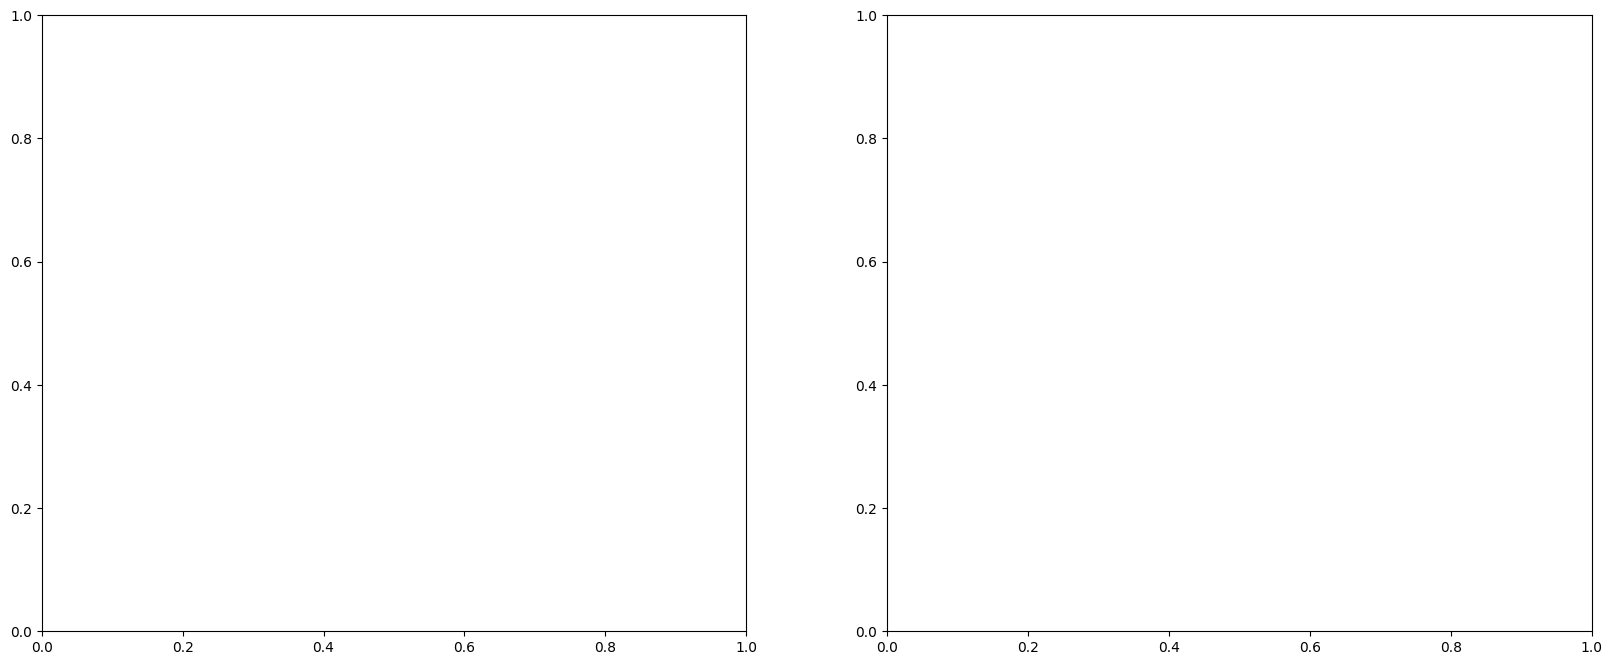

In [16]:
import matplotlib as mpl

fig, axs = plt.subplots(1,2,figsize=(20,8), sharex=True)
flat_ax = axs.flat

## num sales
(100*((rural.price.mean() / urban.price.mean()) - 1)).plot(ax=flat_ax[0])
#flat_ax[0].yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
flat_ax[0].tick_params(axis='both', labelsize=18)
flat_ax[0].set_xlabel('')
flat_ax[0].set_ylabel('% rural uplift in average price', fontsize=20)
flat_ax[0].axhline(y=0, ls='dashed', color='red')
flat_ax[0].axvline(x='2020-04', ls='dotted', color='k')


## num sales
(100*(rural.size()/urban.size())).plot(ax=flat_ax[1])
#flat_ax[1].yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
flat_ax[1].tick_params(axis='both', labelsize=18)
flat_ax[1].set_xlabel('')
flat_ax[1].set_ylabel('% sales that are rural', fontsize=20)
flat_ax[1].axvline(x='2020-04', ls='dotted', color='k')
plt.tight_layout()

for label, ax in zip(['a)', 'b)'], flat_ax):
    # label physical distance to the left and up:
    trans = mtransforms.ScaledTranslation(-20/72, 7/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, label, transform=ax.transAxes + trans,
            fontsize=18, va='bottom', fontfamily='serif', weight='bold')


plt.savefig('../results/pct_numbers_urban_rural_split.png', dpi=300, bbox_inches='tight')

plt.show()


# fig, ax = plt.subplots(figsize=(20,12))
# rural = smaller[smaller.urb_rur == 'Rural']
# rural = rural.groupby('month_year').price.mean().reset_index()
# rural.columns = ['month_year', 'avg_price_base']

# rural.plot(ax=ax, x='month_year', y='avg_price_base', label='Rural')
# base.plot(ax=ax, x='month_year', y='avg_price_base', label='Urban')
# ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
# plt.legend(fontsize=20)
# plt.xlabel('Date', fontsize=22)
# plt.xticks(fontsize=20)
# plt.ylabel('Average price (GBP)', fontsize=22)
# plt.yticks(fontsize=20)
# plt.tight_layout()
# plt.savefig('../results/avg_price_over_time.png', dpi=300, bbox_inches='tight')
# plt.show()

In [8]:
base_reference = smaller[smaller.RUC11 == 'Urban city and town'].groupby('month_year')
all_reference = smaller.groupby('month_year')

In [9]:
smaller.groupby('RUC11').size().sort_values(ascending=False).head(10)

RUC11
Urban city and town                                         13548498
Urban major conurbation                                      8273833
Rural town and fringe                                        2748569
Rural village                                                1359805
Urban minor conurbation                                       866982
Rural hamlets and isolated dwellings                          663460
Rural town and fringe in a sparse setting                     166427
Rural village in a sparse setting                             137580
Rural hamlets and isolated dwellings in a sparse setting       78614
Urban city and town in a sparse setting                        75938
dtype: int64

In [28]:
to_keep = [
    # 'Urban major conurbation',
    'Rural town and fringe',
    'Rural village',
    # 'Urban minor conurbation',
    'Rural hamlets and isolated dwellings',
    'Rural town and fringe in a sparse setting',
]

In [29]:
import matplotlib.colors as mcolors

col_list = list(mcolors.TABLEAU_COLORS.values())

In [30]:
col_list

['#1f77b4',
 '#ff7f0e',
 '#2ca02c',
 '#d62728',
 '#9467bd',
 '#8c564b',
 '#e377c2',
 '#7f7f7f',
 '#bcbd22',
 '#17becf']

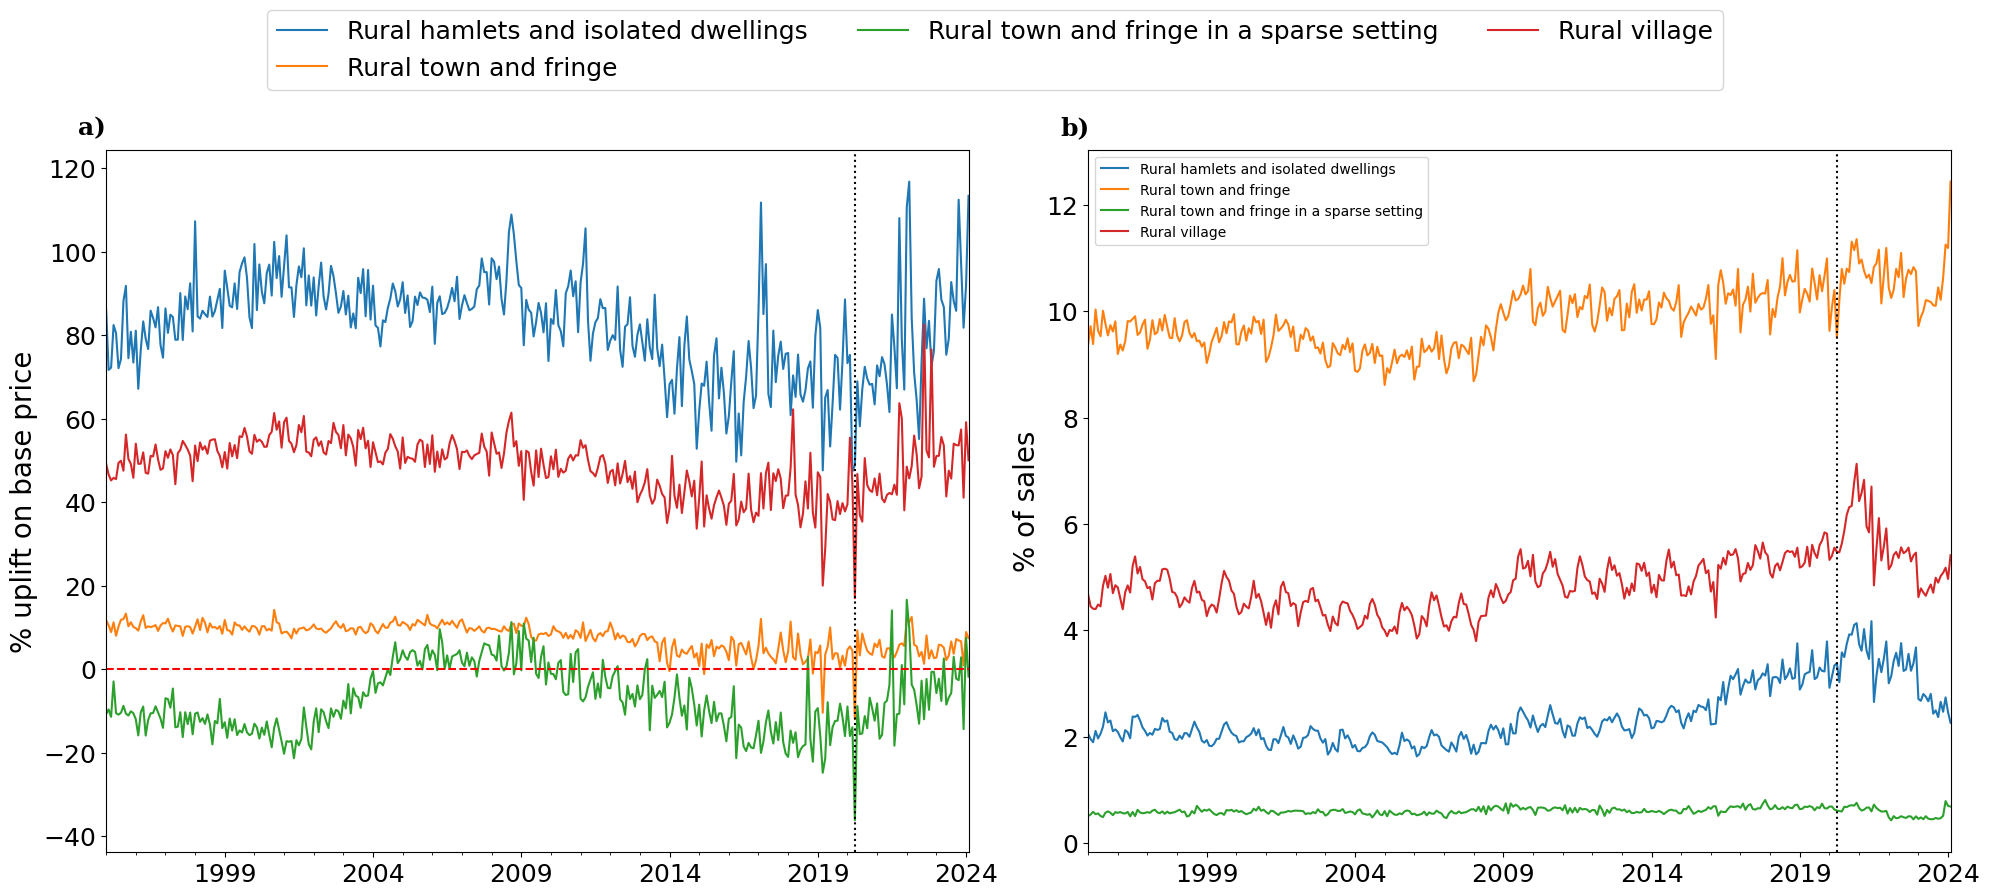

In [31]:
import matplotlib as mpl

fig, axs = plt.subplots(1,2,figsize=(20,8), sharex=True)
flat_ax = axs.flat

i = 0
## num sales
for idx, frame in smaller[(smaller.RUC11.isin(to_keep))].groupby('RUC11'):
    ls = 'dashed' if idx.split(' ')[0] == 'Urban' else 'solid'
    (100*((frame.groupby('month_year').price.mean() / base_reference.price.mean()) - 1)).plot(ax=flat_ax[0], legend=False, label=idx, ls=ls, color=col_list[i])
    (100*frame.groupby('month_year').size()/all_reference.size()).plot(ax=flat_ax[1], legend=True, label=idx, ls=ls, color=col_list[i])
    i +=  1
    
#flat_ax[0].yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
flat_ax[0].tick_params(axis='both', labelsize=18)
flat_ax[0].set_xlabel('')
flat_ax[0].set_ylabel('% uplift on base price', fontsize=20)
flat_ax[0].axhline(y=0, ls='dashed', color='red')
flat_ax[0].axvline(x='2020-04', ls='dotted', color='k')


## num sales
# (100*(rural.size()/urban.size())).plot(ax=flat_ax[1])
#flat_ax[1].yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
flat_ax[1].tick_params(axis='both', labelsize=18)
flat_ax[1].set_xlabel('')
flat_ax[1].set_ylabel('% of sales', fontsize=20)
flat_ax[1].axvline(x='2020-04', ls='dotted', color='k')
plt.tight_layout()

for label, ax in zip(['a)', 'b)'], flat_ax):
    # label physical distance to the left and up:
    trans = mtransforms.ScaledTranslation(-20/72, 7/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, label, transform=ax.transAxes + trans,
            fontsize=18, va='bottom', fontfamily='serif', weight='bold')

handles, labels = flat_ax[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, fontsize=18, bbox_to_anchor = (0, 0.13, 1, 1), frameon=True, fancybox=True)
plt.tight_layout()
plt.savefig('../results/pct_numbers_split_by_ruc_type.png', dpi=300, bbox_inches='tight')

plt.show()


In [216]:
pd.DataFrame(pct_sales)

,0
month_year,
1995-01,17.346688
1995-02,17.291662
1995-03,16.944143
1995-04,17.660927
1995-05,17.256563
...,...
2023-10,18.943037
2023-11,19.314134
2023-12,20.687493


In [273]:
pct_sales = pd.DataFrame(100*rural.size()/(rural.size() + urban.size()))
sales_algo = rpt.Pelt(model="rbf", min_size=1)
sales_algo.fit(pct_sales)
sales_result = sales_algo.predict(pen=3)

pct_price = pd.DataFrame(100*((rural.price.mean() / urban.price.mean()) - 1))
price_algo = rpt.Pelt(model="rbf", min_size=1)
price_algo.fit(pct_price)
price_result = price_algo.predict(pen=3)
# for bkp in sales_result:
#     ax[i].axvline(x=bkp, color='k', linestyle='--')

In [274]:
smaller.month_year.min()

Period('1995-01', 'M')

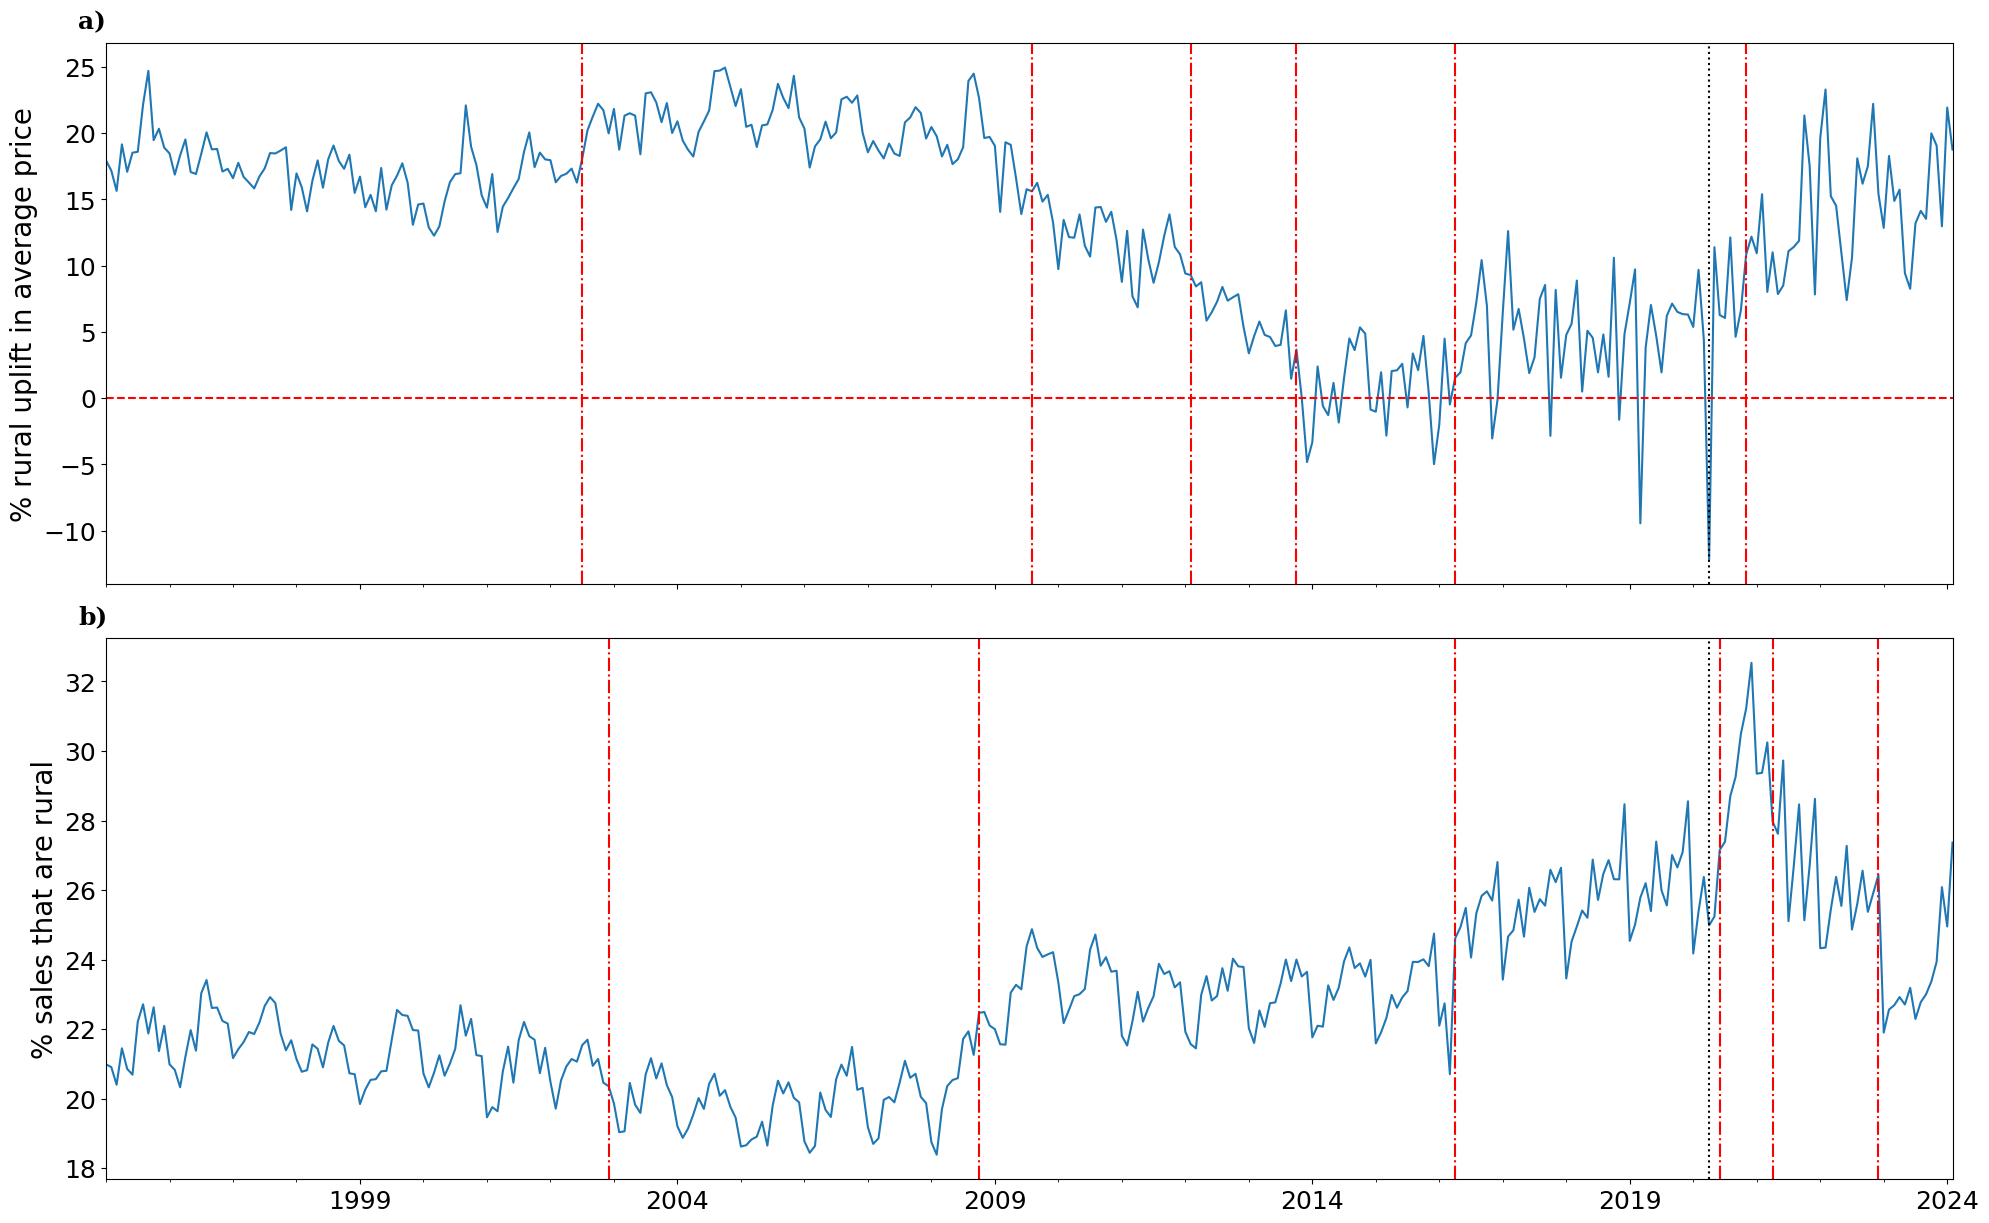

In [279]:
import matplotlib as mpl

fig, axs = plt.subplots(2,1,figsize=(20,12), sharex=True)
flat_ax = axs.flat
price_vallies = []
sale_vallies = []
    
## num sales
(100*((rural.price.mean() / urban.price.mean()) - 1)).plot(ax=flat_ax[0])
#flat_ax[0].yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
flat_ax[0].tick_params(axis='both', labelsize=18)
flat_ax[0].set_xlabel('')
flat_ax[0].set_ylabel('% rural uplift in average price', fontsize=20)
flat_ax[0].axhline(y=0, ls='dashed', color='red')
flat_ax[0].axvline(x='2020-04', ls='dotted', color='k')

for bkp in price_result:
    flat_ax[0].axvline(x=pd.Period('1995-01', 'M') + pd.offsets.MonthEnd(bkp), color='red', linestyle='dashdot')
    price_vallies.append(pd.Period('1995-01', 'M') + pd.offsets.MonthEnd(bkp))


## num sales
(100*(rural.size()/urban.size())).plot(ax=flat_ax[1])
#flat_ax[1].yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
flat_ax[1].tick_params(axis='both', labelsize=18)
flat_ax[1].set_xlabel('')
flat_ax[1].set_ylabel('% sales that are rural', fontsize=20)
flat_ax[1].axvline(x='2020-04', ls='dotted', color='k')
for bkp in sales_result:
    flat_ax[1].axvline(x=pd.Period('1995-01', 'M') + pd.offsets.MonthEnd(bkp), color='red', linestyle='dashdot')
    sale_vallies.append(pd.Period('1995-01', 'M') + pd.offsets.MonthEnd(bkp))
plt.tight_layout()
plt.subplots_adjust(hspace=0.1)

for label, ax in zip(['a)', 'b)'], flat_ax):
    # label physical distance to the left and up:
    trans = mtransforms.ScaledTranslation(-20/72, 7/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, label, transform=ax.transAxes + trans,
            fontsize=18, va='bottom', fontfamily='serif', weight='bold')


plt.savefig('../results/urban_rural_split_with_breakpoints.png', dpi=300, bbox_inches='tight')

plt.show()

In [280]:
price_vallies

[Period('2002-07', 'M'),
 Period('2009-08', 'M'),
 Period('2012-02', 'M'),
 Period('2013-10', 'M'),
 Period('2016-04', 'M'),
 Period('2020-11', 'M'),
 Period('2024-03', 'M')]

In [281]:
sale_vallies

[Period('2002-12', 'M'),
 Period('2008-10', 'M'),
 Period('2016-04', 'M'),
 Period('2020-06', 'M'),
 Period('2021-04', 'M'),
 Period('2022-12', 'M'),
 Period('2024-03', 'M')]

## Specific LADs

In [282]:
most_rural.sort_values(by='num_sales', ascending=False).head(25)

,LAD22NM,pct_rural,num_sales
17,Birmingham,0.000477,413202.0
154,Leeds,0.062132,376583.0
68,Cornwall,0.599959,301844.0
40,Buckinghamshire,0.303900,273458.0
317,Wiltshire,0.394898,254139.0
70,County Durham,0.457250,251987.0
27,Bradford,0.085437,245937.0
25,"Bournemouth, Christchurch and Poole",0.001667,245933.0
312,West Northamptonshire,0.294621,231131.0
239,Sheffield,0.019729,230062.0


In [312]:
to_keep = [
    'Cornwall',
    'Buckinghamshire',
    'Wiltshire',
    'County Durham',
    'West Northamptonshire',
]

In [313]:
base_reference = smaller[smaller.RUC11 == 'Urban city and town'].groupby('month_year')
all_reference = smaller.groupby('month_year')

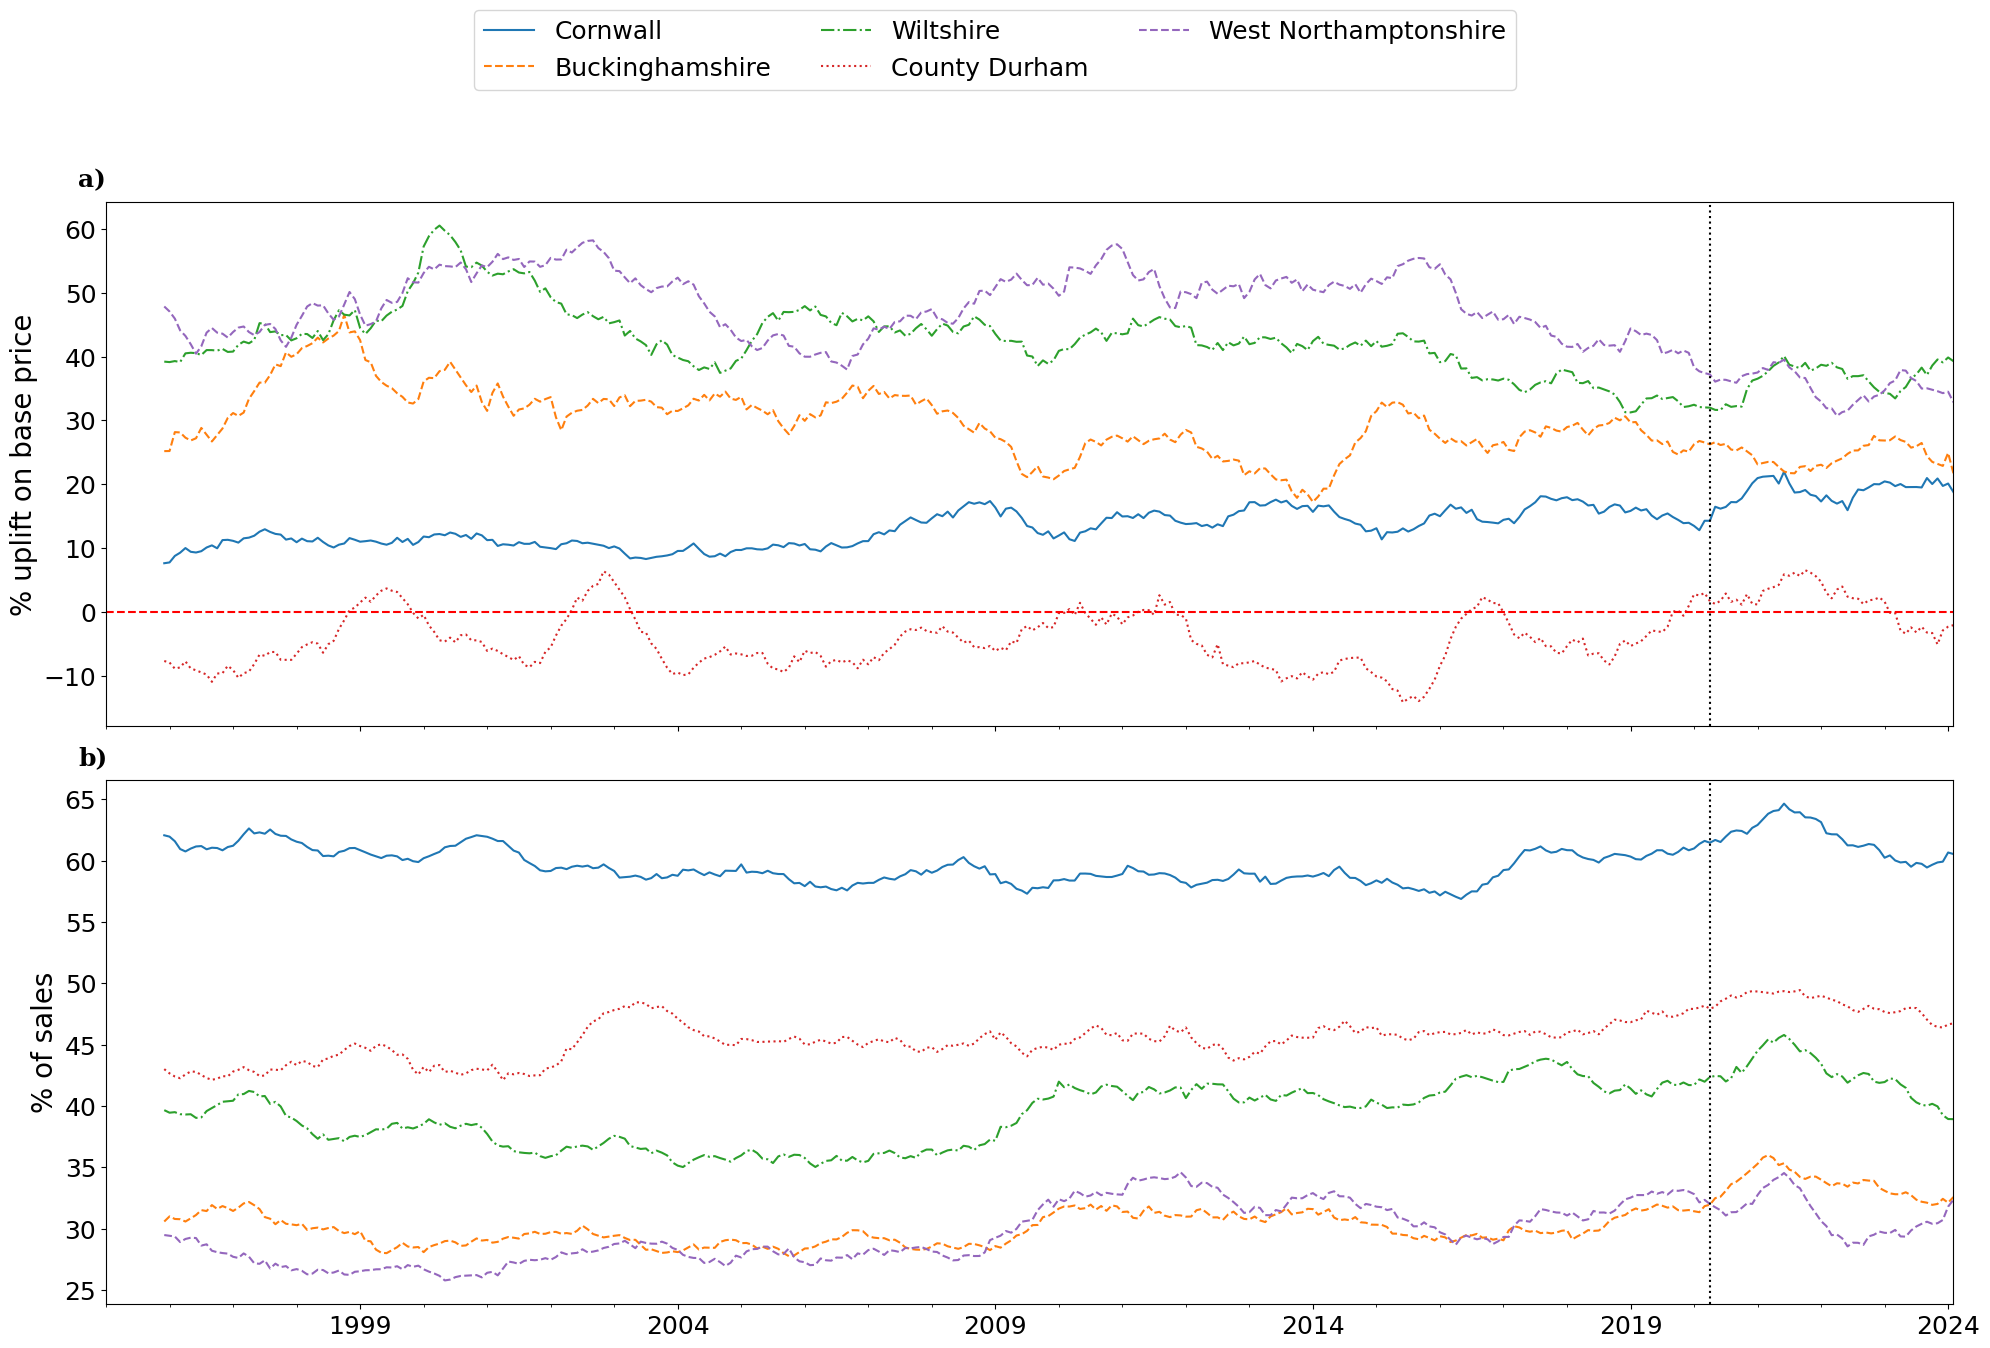

In [314]:
import matplotlib as mpl

fig, axs = plt.subplots(2,1,figsize=(20,12), sharex=True)
flat_ax = axs.flat

i = 0
ls = ['-', '--', '-.', ':', '--']
## num sales
for lad in to_keep:
    frame = smaller[smaller.LAD22NM == lad]
    urban_f = frame[frame.urb_rur == 'Urban'].groupby('month_year')
    rural_f = frame[frame.urb_rur == 'Rural'].groupby('month_year')
    (100*((rural_f.price.median() / urban_f.price.median()) - 1)).rolling(12).mean().plot(ax=flat_ax[0], legend=False, label=lad, ls=ls[i%len(ls)])
    (100*rural_f.size()/(urban_f.size() + rural_f.size())).rolling(12).mean().plot(ax=flat_ax[1], legend=False, label=lad, ls=ls[i%len(ls)])
    i += 1
    
#flat_ax[0].yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
flat_ax[0].tick_params(axis='both', labelsize=18)
flat_ax[0].set_xlabel('')
flat_ax[0].set_ylabel('% uplift on base price', fontsize=20)
flat_ax[0].axhline(y=0, ls='dashed', color='red')
flat_ax[0].axvline(x='2020-04', ls='dotted', color='k')


#flat_ax[1].yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
flat_ax[1].tick_params(axis='both', labelsize=18)
flat_ax[1].set_xlabel('')
flat_ax[1].set_ylabel('% of sales', fontsize=20)
flat_ax[1].axvline(x='2020-04', ls='dotted', color='k')
plt.tight_layout()

for label, ax in zip(['a)', 'b)'], flat_ax):
    # label physical distance to the left and up:
    trans = mtransforms.ScaledTranslation(-20/72, 7/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, label, transform=ax.transAxes + trans,
            fontsize=18, va='bottom', fontfamily='serif', weight='bold')

handles, labels = flat_ax[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, fontsize=18, bbox_to_anchor = (0, 0.13, 1, 1), frameon=True, fancybox=True)
plt.tight_layout()
plt.savefig('../results/pct_numbers_split_by_lad.png', dpi=300, bbox_inches='tight')

plt.show()


month_year
1995-01          NaN
1995-02          NaN
1995-03          NaN
1995-04          NaN
1995-05          NaN
             ...    
2023-10    38.622084
2023-11    40.473144
2023-12    41.178995
2024-01    41.257120
2024-02    38.266072
Freq: M, Name: price, Length: 350, dtype: float64

In [315]:
smaller.head()

,Unnamed: 0,id,price,date,postcode,property_type,old_new,duration,paon,saon,...,y_coord,lat,lon,OA11CD,LAD22NM,RUC11CD,RUC11,datey,month_year,urb_rur
0,0,{8524B47D-47ED-4C6B-97BF-D114570165DE},56950,1995-10-20 00:00,ST5 7UE,D,Y,F,2,NaN,...,350560.34,53.052039,-2.257366,E00150541,Newcastle-under-Lyme,C1,Urban city and town,1995-10-20,1995-10,Urban
1,1,{92A77299-BCFF-433B-B54D-D114861197D7},56952,1995-03-31 00:00,SE16 3EY,F,Y,L,3,FLAT 27,...,178381.00,51.488331,-0.060520,E00020342,Southwark,A1,Urban major conurbation,1995-03-31,1995-03,Urban
2,2,{AECA5453-F149-46BF-B3E3-CA05B7E47CE5},74000,1995-12-01 00:00,DY8 5PW,D,N,F,66,NaN,...,287130.00,52.481988,-2.167445,E00050170,Dudley,A1,Urban major conurbation,1995-12-01,1995-12,Urban
3,3,{6785BDEE-16CA-4D80-8131-CA05D4F4DBE0},155000,1995-08-09 00:00,OX39 4AF,D,Y,F,THE PANTILES,NaN,...,202835.00,51.719093,-0.899908,E00145755,South Oxfordshire,F1,Rural hamlets and isolated dwellings,1995-08-09,1995-08,Rural
4,4,{3FAA4BB3-40B8-4003-8C5B-D494636C6410},75000,1995-09-08 00:00,SN9 5HD,D,N,F,6,NaN,...,160302.00,51.341568,-1.766247,E00162545,Wiltshire,D1,Rural town and fringe,1995-09-08,1995-09,Rural


In [316]:
smaller.groupby('LAD22NM').price.mean().sort_values(ascending=False).head(20)

LAD22NM
City of London            1.308631e+06
Kensington and Chelsea    1.138671e+06
Westminster               1.017683e+06
Camden                    7.266175e+05
Hammersmith and Fulham    6.072553e+05
Elmbridge                 5.139251e+05
Islington                 5.096179e+05
Richmond upon Thames      5.010471e+05
Wandsworth                4.721823e+05
Hackney                   4.103322e+05
Southwark                 3.984843e+05
Barnet                    3.962802e+05
Windsor and Maidenhead    3.933197e+05
Lambeth                   3.905959e+05
Waverley                  3.889485e+05
St Albans                 3.849238e+05
Haringey                  3.847496e+05
Mole Valley               3.846539e+05
Tower Hamlets             3.820856e+05
Merton                    3.708819e+05
Name: price, dtype: float64

In [317]:
smaller.groupby('LAD22NM').price.mean().sort_values(ascending=True).head(20)

LAD22NM
Blaenau Gwent               74341.405620
Burnley                     79084.878468
Hyndburn                    85715.268826
Merthyr Tydfil              85934.239455
Kingston upon Hull          90067.177533
Rhondda Cynon Taf           91291.078602
Stoke-on-Trent              93884.771707
Neath Port Talbot           94503.822188
Pendle                      95595.916863
Blackpool                   97147.503576
Barrow-in-Furness           98741.957587
Blackburn with Darwen      101426.891632
North East Lincolnshire    101929.611182
Hartlepool                 104369.701146
Caerphilly                 104435.365980
Middlesbrough              108475.192388
Copeland                   110394.537761
Oldham                     111250.420028
County Durham              111949.388957
Redcar and Cleveland       112460.423395
Name: price, dtype: float64

In [318]:
smaller.shape

(27919706, 31)

In [319]:
smaller.head()

,Unnamed: 0,id,price,date,postcode,property_type,old_new,duration,paon,saon,...,y_coord,lat,lon,OA11CD,LAD22NM,RUC11CD,RUC11,datey,month_year,urb_rur
0,0,{8524B47D-47ED-4C6B-97BF-D114570165DE},56950,1995-10-20 00:00,ST5 7UE,D,Y,F,2,NaN,...,350560.34,53.052039,-2.257366,E00150541,Newcastle-under-Lyme,C1,Urban city and town,1995-10-20,1995-10,Urban
1,1,{92A77299-BCFF-433B-B54D-D114861197D7},56952,1995-03-31 00:00,SE16 3EY,F,Y,L,3,FLAT 27,...,178381.00,51.488331,-0.060520,E00020342,Southwark,A1,Urban major conurbation,1995-03-31,1995-03,Urban
2,2,{AECA5453-F149-46BF-B3E3-CA05B7E47CE5},74000,1995-12-01 00:00,DY8 5PW,D,N,F,66,NaN,...,287130.00,52.481988,-2.167445,E00050170,Dudley,A1,Urban major conurbation,1995-12-01,1995-12,Urban
3,3,{6785BDEE-16CA-4D80-8131-CA05D4F4DBE0},155000,1995-08-09 00:00,OX39 4AF,D,Y,F,THE PANTILES,NaN,...,202835.00,51.719093,-0.899908,E00145755,South Oxfordshire,F1,Rural hamlets and isolated dwellings,1995-08-09,1995-08,Rural
4,4,{3FAA4BB3-40B8-4003-8C5B-D494636C6410},75000,1995-09-08 00:00,SN9 5HD,D,N,F,6,NaN,...,160302.00,51.341568,-1.766247,E00162545,Wiltshire,D1,Rural town and fringe,1995-09-08,1995-09,Rural


In [334]:
import re
cmp = re.compile(r'^([A-Z]+)')
def extract_first_letters(postcode):
    try:
        match = re.match(cmp, postcode)
        if match:
            return match.group(1)
        else:
            return None
    except:
        return None

In [335]:
extract_first_letters('ST5 7UE')

'ST'

In [336]:
smaller.loc[:, 'postcode_bit'] = smaller.postcode.apply(extract_first_letters)
smaller.head()

,Unnamed: 0,id,price,date,postcode,property_type,old_new,duration,paon,saon,...,lat,lon,OA11CD,LAD22NM,RUC11CD,RUC11,datey,month_year,urb_rur,postcode_bit
0,0,{8524B47D-47ED-4C6B-97BF-D114570165DE},56950,1995-10-20 00:00,ST5 7UE,D,Y,F,2,NaN,...,53.052039,-2.257366,E00150541,Newcastle-under-Lyme,C1,Urban city and town,1995-10-20,1995-10,Urban,ST
1,1,{92A77299-BCFF-433B-B54D-D114861197D7},56952,1995-03-31 00:00,SE16 3EY,F,Y,L,3,FLAT 27,...,51.488331,-0.060520,E00020342,Southwark,A1,Urban major conurbation,1995-03-31,1995-03,Urban,SE
2,2,{AECA5453-F149-46BF-B3E3-CA05B7E47CE5},74000,1995-12-01 00:00,DY8 5PW,D,N,F,66,NaN,...,52.481988,-2.167445,E00050170,Dudley,A1,Urban major conurbation,1995-12-01,1995-12,Urban,DY
3,3,{6785BDEE-16CA-4D80-8131-CA05D4F4DBE0},155000,1995-08-09 00:00,OX39 4AF,D,Y,F,THE PANTILES,NaN,...,51.719093,-0.899908,E00145755,South Oxfordshire,F1,Rural hamlets and isolated dwellings,1995-08-09,1995-08,Rural,OX
4,4,{3FAA4BB3-40B8-4003-8C5B-D494636C6410},75000,1995-09-08 00:00,SN9 5HD,D,N,F,6,NaN,...,51.341568,-1.766247,E00162545,Wiltshire,D1,Rural town and fringe,1995-09-08,1995-09,Rural,SN


In [337]:
smaller.groupby('postcode_bit').size().sort_values(ascending=False).head(10)

postcode_bit
B     793091
S     597859
NG    586640
NE    551628
M     546542
BS    515119
PE    514439
BN    501628
LE    478098
PO    475284
dtype: int64

In [346]:
london_list = [
    'E',
    'EC',
    'N',
    'NW',
    'SE',
    'SW',
    'W',
    'WC',
    'B'
]

In [347]:
smaller[smaller.postcode_bit.isin(london_list)].shape

(2802410, 32)

In [348]:
smaller.shape

(27919706, 32)

In [349]:
london_only = smaller[smaller.postcode_bit.isin(london_list)]
london_only.head()

,Unnamed: 0,id,price,date,postcode,property_type,old_new,duration,paon,saon,...,lat,lon,OA11CD,LAD22NM,RUC11CD,RUC11,datey,month_year,urb_rur,postcode_bit
1,1,{92A77299-BCFF-433B-B54D-D114861197D7},56952,1995-03-31 00:00,SE16 3EY,F,Y,L,3,FLAT 27,...,51.488331,-0.060520,E00020342,Southwark,A1,Urban major conurbation,1995-03-31,1995-03,Urban,SE
20,20,{3029234C-6901-4499-8655-CD7EBF71CAA2},78950,1995-11-24 00:00,B75 7RW,D,N,F,72,NaN,...,52.569163,-1.801642,E00175741,Birmingham,A1,Urban major conurbation,1995-11-24,1995-11,Urban,B
24,24,{46B00023-9D01-4224-8864-D114E9FCEF81},108500,1995-09-22 00:00,B43 6DY,D,N,F,8,NaN,...,52.546045,-1.935407,E00050440,Sandwell,A1,Urban major conurbation,1995-09-22,1995-09,Urban,B
39,39,{5DD0974F-8C58-4D63-B96D-D11514E2EF0C},56000,1995-11-30 00:00,E17 6QY,T,N,F,15,NaN,...,51.588689,-0.029210,E00022412,Waltham Forest,A1,Urban major conurbation,1995-11-30,1995-11,Urban,E
41,41,{11534F1D-F156-4892-B365-CA06AABABB61},29000,1995-06-23 00:00,B98 7XJ,F,N,L,55,NaN,...,52.285587,-1.942526,E00164534,Redditch,C1,Urban city and town,1995-06-23,1995-06,Urban,B


In [350]:
no_london = smaller[~smaller.postcode_bit.isin(london_list)]
no_london.head()

,Unnamed: 0,id,price,date,postcode,property_type,old_new,duration,paon,saon,...,lat,lon,OA11CD,LAD22NM,RUC11CD,RUC11,datey,month_year,urb_rur,postcode_bit
0,0,{8524B47D-47ED-4C6B-97BF-D114570165DE},56950,1995-10-20 00:00,ST5 7UE,D,Y,F,2,NaN,...,53.052039,-2.257366,E00150541,Newcastle-under-Lyme,C1,Urban city and town,1995-10-20,1995-10,Urban,ST
2,2,{AECA5453-F149-46BF-B3E3-CA05B7E47CE5},74000,1995-12-01 00:00,DY8 5PW,D,N,F,66,NaN,...,52.481988,-2.167445,E00050170,Dudley,A1,Urban major conurbation,1995-12-01,1995-12,Urban,DY
3,3,{6785BDEE-16CA-4D80-8131-CA05D4F4DBE0},155000,1995-08-09 00:00,OX39 4AF,D,Y,F,THE PANTILES,NaN,...,51.719093,-0.899908,E00145755,South Oxfordshire,F1,Rural hamlets and isolated dwellings,1995-08-09,1995-08,Rural,OX
4,4,{3FAA4BB3-40B8-4003-8C5B-D494636C6410},75000,1995-09-08 00:00,SN9 5HD,D,N,F,6,NaN,...,51.341568,-1.766247,E00162545,Wiltshire,D1,Rural town and fringe,1995-09-08,1995-09,Rural,SN
5,5,{49A6A979-61D4-4F09-89C8-D4946C42987E},12500,1995-08-25 00:00,OL13 0EA,T,N,L,10,NaN,...,53.691641,-2.209593,E00128748,Rossendale,C1,Urban city and town,1995-08-25,1995-08,Urban,OL


In [351]:
no_london_urban = no_london[no_london.urb_rur == 'Urban'].groupby('month_year')
no_london_rural = no_london[no_london.urb_rur == 'Rural'].groupby('month_year')

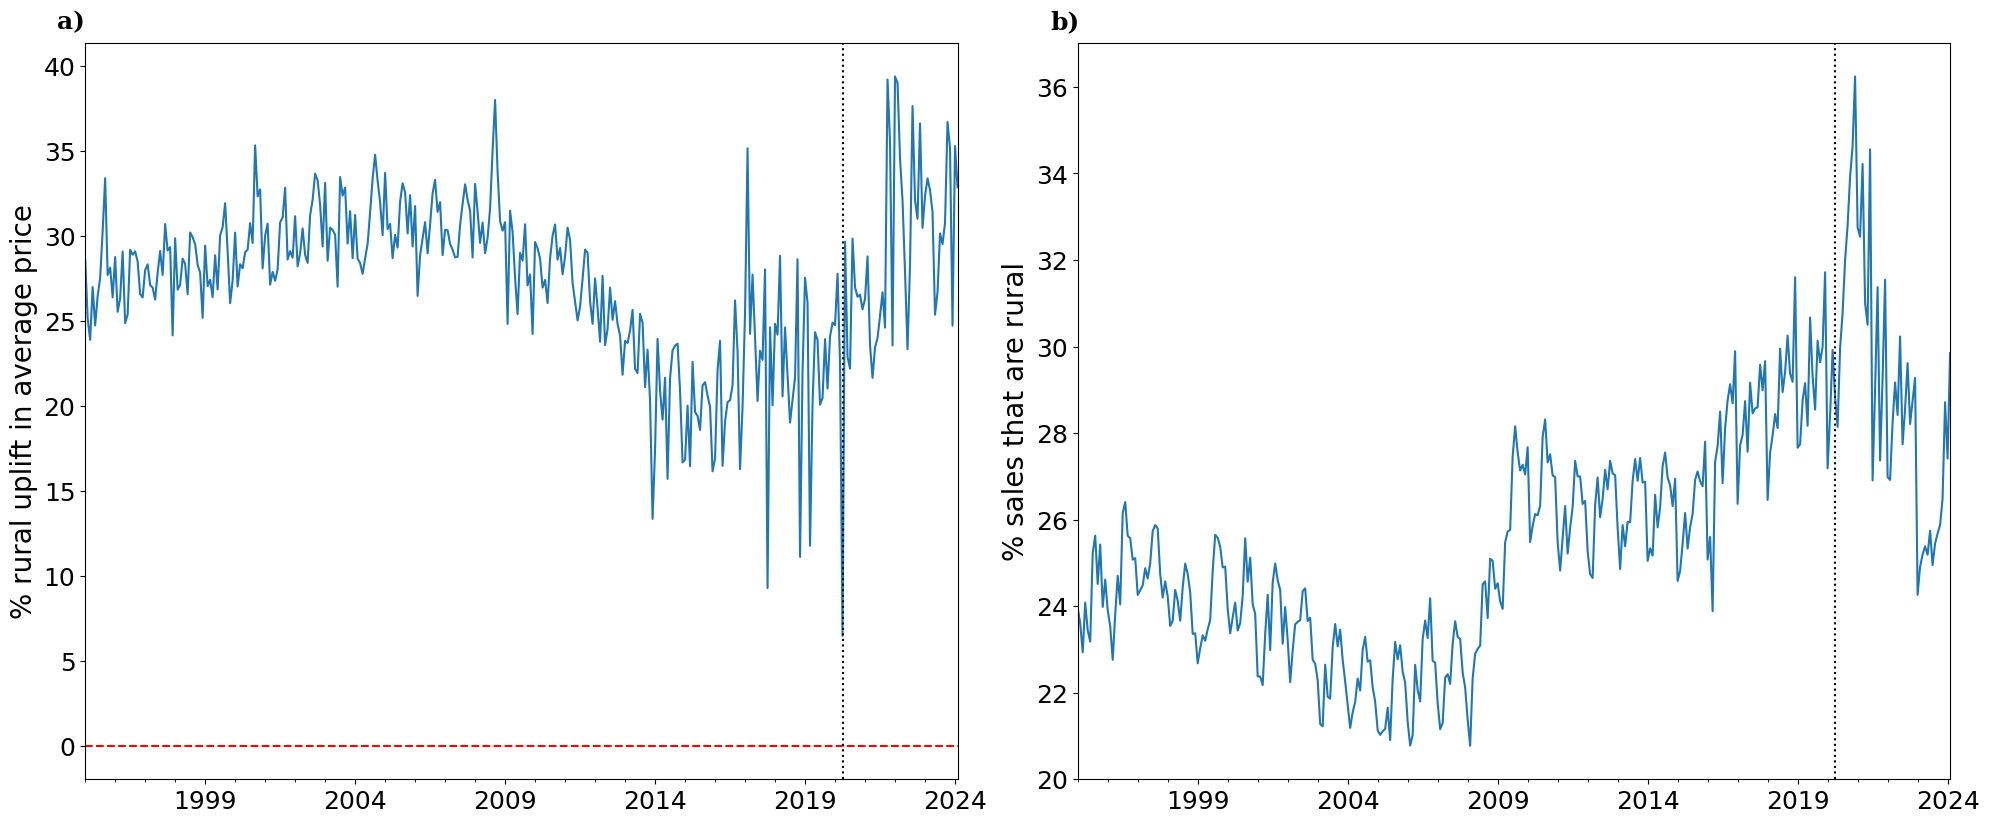

In [352]:
import matplotlib as mpl

fig, axs = plt.subplots(1,2,figsize=(20,8), sharex=True)
flat_ax = axs.flat

## num sales
(100*((no_london_rural.price.mean() / no_london_urban.price.mean()) - 1)).plot(ax=flat_ax[0])
#flat_ax[0].yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
flat_ax[0].tick_params(axis='both', labelsize=18)
flat_ax[0].set_xlabel('')
flat_ax[0].set_ylabel('% rural uplift in average price', fontsize=20)
flat_ax[0].axhline(y=0, ls='dashed', color='red')
flat_ax[0].axvline(x='2020-04', ls='dotted', color='k')


## num sales
(100*(no_london_rural.size()/no_london_urban.size())).plot(ax=flat_ax[1])
#flat_ax[1].yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
flat_ax[1].tick_params(axis='both', labelsize=18)
flat_ax[1].set_xlabel('')
flat_ax[1].set_ylabel('% sales that are rural', fontsize=20)
flat_ax[1].axvline(x='2020-04', ls='dotted', color='k')
plt.tight_layout()

for label, ax in zip(['a)', 'b)'], flat_ax):
    # label physical distance to the left and up:
    trans = mtransforms.ScaledTranslation(-20/72, 7/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, label, transform=ax.transAxes + trans,
            fontsize=18, va='bottom', fontfamily='serif', weight='bold')


plt.savefig('../results/pct_numbers_urban_rural_split_no_london_brum.png', dpi=300, bbox_inches='tight')

plt.show()


# fig, ax = plt.subplots(figsize=(20,12))
# rural = smaller[smaller.urb_rur == 'Rural']
# rural = rural.groupby('month_year').price.mean().reset_index()
# rural.columns = ['month_year', 'avg_price_base']

# rural.plot(ax=ax, x='month_year', y='avg_price_base', label='Rural')
# base.plot(ax=ax, x='month_year', y='avg_price_base', label='Urban')
# ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
# plt.legend(fontsize=20)
# plt.xlabel('Date', fontsize=22)
# plt.xticks(fontsize=20)
# plt.ylabel('Average price (GBP)', fontsize=22)
# plt.yticks(fontsize=20)
# plt.tight_layout()
# plt.savefig('../results/avg_price_over_time.png', dpi=300, bbox_inches='tight')
# plt.show()

In [353]:
to_keep = [
    'Urban major conurbation',
    'Rural town and fringe',
    'Rural village',
    'Urban minor conurbation',
    'Rural hamlets and isolated dwellings',
]

In [375]:
to_use = smaller[smaller.RUC11.isin(['Rural hamlets and isolated dwellings', 'Urban major conurbation'])].groupby(['RUC11', 'month_year']).size().reset_index()
to_use.columns = ['RUC11', 'month_year', 'num_sales']
p = to_use.pivot(index='month_year', columns='RUC11', values='num_sales')
p.tail()

RUC11,Rural hamlets and isolated dwellings,Urban major conurbation
month_year,,
2023-10,1264,13961
2023-11,817,9522
2023-12,480,4771
2024-01,374,4243
2024-02,172,1874


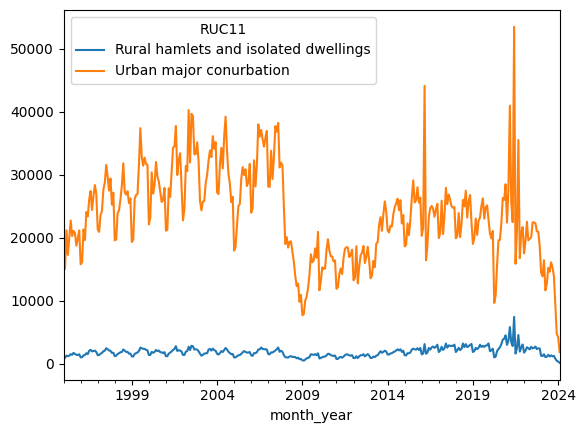

In [376]:
p.plot()
plt.show()

In [379]:
all_reference.size()

month_year
1995-01    48822
1995-02    49307
1995-03    69015
1995-04    58536
1995-05    65859
           ...  
2023-10    47627
2023-11    33126
2023-12    17542
2024-01    15228
2024-02     7614
Freq: M, Length: 350, dtype: int64

In [1]:
import matplotlib as mpl

fig, axs = plt.subplots(1,1,figsize=(20,8))
flat_ax = axs

## num sales
for idx, frame in smaller[(smaller.RUC11.isin(to_keep))].groupby('RUC11'):
    ls = 'dashed' if idx.split(' ')[0] == 'Urban' else 'solid'
    (100*(frame.groupby('month_year').size())/all_reference.size()).plot(ax=axs, legend=False, label=idx, ls=ls)
    
#flat_ax[0].yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
axs.tick_params(axis='both', labelsize=18)
axs.set_xlabel('')
axs.set_ylabel('% uplift on base price', fontsize=20)
# axs.axhline(y=0, ls='dashed', color='red')
axs.axvline(x='2020-04', ls='dotted', color='k')


handles, labels = axs.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, fontsize=18, bbox_to_anchor = (0, 0.13, 1, 1), frameon=True, fancybox=True)
plt.tight_layout()
# plt.savefig('../results/pct_numbers_split_by_ruc_type.png', dpi=300, bbox_inches='tight')

plt.show()

NameError: name 'plt' is not defined

In [389]:
(100*frame.groupby('month_year').size()/all_reference.size())

month_year
1995-01    3.051903
1995-02    3.048249
1995-03    3.028327
1995-04    3.054531
1995-05    3.009460
             ...   
2023-10    3.569404
2023-11    3.716114
2023-12    3.340554
2024-01    3.808773
2024-02    3.546099
Freq: M, Length: 350, dtype: float64